## 1. What this notebook computes

The author's eight gamma matrices are ONE solution of the Clifford relation
$\gamma^a\gamma^b + \gamma^b\gamma^a = 2\eta^{ab} I_{16}$ with
$\eta = \mathrm{diag}(+1, +1, +1, -1, -1, -1, -1, +1)$ in the order of his
coordinates $x_1, \dots, x_8$. Are they special? This notebook answers the question
exactly. It

- builds a second set of eight real $16 \times 16$ matrices $\hat\gamma^{(x_a)}$
  ("gamma hat") from three $2 \times 2$ matrices P, N and G with the *Kronecker
  product*, a recipe that needs no notebook of the author at all;
- checks exactly that the new set satisfies the same Clifford relation, has the same
  symmetry pattern, and that its 256 products are independent;
- compares the products of all eight gammas in both sets (the *chirality product*);
- constructs, with one formula, the change of basis that turns the new set into the
  author's: a $16 \times 16$ signed permutation matrix $Q$ with
  $\gamma^{(x_a)} = Q\,\hat\gamma^{(x_a)} Q^T$ for all eight directions, so the
  author's matrices are the new ones with the 16 components renumbered and some of
  their signs flipped;
- proves exactly that this change of basis is unique up to a factor, and reproduces
  the Revision record's result that only multiples of the identity commute with all
  eight of the author's gammas;
- distributes the $2 \times 2$ blocks in another way and shows that a change of
  basis still exists but is no longer a signed permutation, and why;
- draws six figures.

## 2. How to run this notebook

**Step 1. What this notebook does and what it needs.**

Notebook 04d (A second set of gammas from tensor products, and the change of basis to the
author's T16) is the file `Revision/textbook/notebooks/04d_tensor_gammas.ipynb` of the
repository Dirac_claude. It builds a second set of eight real 16 by 16 gamma matrices for
the author's 4+4 directions from three 2 by 2 matrices with Kronecker (tensor) products,
checks exactly that they satisfy the same Clifford relation, and constructs the change of
basis that turns them into the author's gammas: a signed permutation matrix Q with gamma
= Q times the tensor gamma times the transpose of Q for all eight directions. It proves
exactly that this change of basis is unique up to a factor (the solution space has
dimension 1; the commutant of the author's gammas has dimension 1, as the Revision record
found), shows what changes when the 2 by 2 blocks are distributed differently, and draws
six figures. It needs a computer with Windows 11, macOS or Linux, an internet connection
for the installation, the program Git, and Python 3.12 or newer (the notebooks were built
with Python 3.14.5) with these packages at exactly these versions: numpy 2.4.6, sympy
1.14.0, mpmath 1.3.0, matplotlib 3.11.0, jupyterlab 4.4.10, nbformat 5.10.4, nbclient
0.10.2, ipykernel 7.1.0 and nbconvert 7.16.6. The notebook itself imports numpy, sympy
and matplotlib; the other packages run Jupyter, the program that shows and runs
notebooks. It does not need Rust.

**Step 2. Install Git and Python (once per computer).**

A terminal is the window in which you type commands: on Windows the app Windows
PowerShell (or Terminal), on macOS the app Terminal (it runs the shell zsh), on Linux any
terminal (it runs the shell bash). Type every command of this section into a terminal
exactly as printed, one line at a time, and press Enter after each line.

Windows: download Git from https://git-scm.com/download/win and install it with the
default choices. Download Python from https://www.python.org/downloads/ and run the
installer; in its first window tick the box "Add python.exe to PATH" before you click
"Install Now".

macOS: download Python from https://www.python.org/downloads/ and run the installer. Then
open the app Terminal and run this command, which installs Git and the compiler tools:

macOS (zsh):

    xcode-select --install

Linux (Debian or Ubuntu; other distributions have packages of the same names): run these
two commands:

Linux (bash):

    sudo apt update
    sudo apt install git python3 python3-venv

Then close the terminal and open a NEW one (a terminal opened before the installation
does not know the new programs), and check the version of Python; it must print 3.12 or a
higher number:

Windows (PowerShell):

    py -3 --version

macOS (zsh) and Linux (bash):

    python3 --version

If an older Linux prints a lower number (Ubuntu 22.04 has Python 3.10), install Python
3.12 with the following three commands, and in Step 3 type `python3.12` instead of
`python3` in the command that creates the environment:

Linux (bash), only when the version is too low:

    sudo add-apt-repository ppa:deadsnakes/ppa
    sudo apt update
    sudo apt install python3.12 python3.12-venv

**Step 3. Get the repository and install the packages (once per computer).**

The commands below download the repository (about 130 MB; the folder then takes about 400
MB of disk space) into the folder Dirac_claude inside your home folder, create a private
Python environment in the folder dirac-book-env inside your home folder (a private
environment is a folder with its own copy of Python and of the packages, so that nothing
else on your computer is changed), activate it (from then on the commands `python` and
`jupyter` typed in this terminal are those of the environment, and the prompt starts with
(dirac-book-env)), and install the packages at the pinned versions (this downloads about
90 MB and takes a few minutes; the environment takes about 400 MB of disk space). If you
have done this step before, for this or for another notebook, skip it and go to Step 4;
to get the newest version of the repository, run `git pull` in the repository folder
after Step 4.

Windows (PowerShell):

    cd $HOME
    git clone https://github.com/once-ere/Dirac_claude.git
    py -3 -m venv "$HOME\dirac-book-env"
    Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
    & "$HOME\dirac-book-env\Scripts\Activate.ps1"
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

The line with `Set-ExecutionPolicy` allows PowerShell to run the activation script in
this one window only; it changes nothing permanently.

macOS (zsh):

    cd ~
    git clone https://github.com/once-ere/Dirac_claude.git
    python3 -m venv ~/dirac-book-env
    source ~/dirac-book-env/bin/activate
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

Linux (bash):

    cd ~
    git clone https://github.com/once-ere/Dirac_claude.git
    python3 -m venv ~/dirac-book-env
    source ~/dirac-book-env/bin/activate
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

**Step 4. In every new terminal: activate the environment and go into the repository
folder.**

Every later step starts in the repository folder with the environment active. Run these
lines whenever you open a new terminal (they do no harm if the environment is already
active):

Windows (PowerShell):

    Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
    & "$HOME\dirac-book-env\Scripts\Activate.ps1"
    cd "$HOME\Dirac_claude"

macOS (zsh) and Linux (bash):

    source ~/dirac-book-env/bin/activate
    cd ~/Dirac_claude

**Step 5. Run the notebook in JupyterLab.**

In the repository folder, with the environment active, run these two lines (the first one
goes into the folder of the notebooks):

Windows, macOS and Linux:

    cd Revision/textbook/notebooks
    jupyter lab 04d_tensor_gammas.ipynb

JupyterLab opens in your web browser and shows the notebook (if no browser window opens,
copy the address that starts with `http://localhost:8888/lab` from the terminal into the
address bar of your browser). The name at the top right of the notebook must read Python
3 (ipykernel). Choose the menu Run > Run All Cells. While a cell runs, the label to its
left shows `[*]`; when it has finished, the label shows a number. The notebook has
finished when the last code cell shows a number; this takes about 15 seconds on a typical
laptop. Scroll to the end and compare the last printed lines with the lines in the step
"What the notebook writes and what you must see" below. To keep the results, save the
notebook (menu File > Save Notebook). To stop JupyterLab, choose the menu File > Shut
Down, or press Ctrl+C twice in the terminal.

**Step 6. Or run the notebook without a browser (headless).**

In the repository folder, with the environment active, run:

Windows, macOS and Linux:

    cd Revision/textbook/notebooks
    jupyter nbconvert --to notebook --execute --inplace 04d_tensor_gammas.ipynb

This runs every cell from the top to the bottom and saves the results into the notebook
file. A failed check stops it with an error message that contains AssertionError and the
name of the check. If the command ends with a line that starts with `[NbConvertApp]
Writing` and shows no error, every check passed; open the notebook with `jupyter lab
04d_tensor_gammas.ipynb` (in the same folder, without running the cells again) to read
the printed lines and see the figures.

**Step 7. What the notebook writes and what you must see.**

The notebook writes (or overwrites) these files:

- `Revision/textbook/figures/04d.captions.json`
- `Revision/textbook/figures/04d_1_slot_pattern.png`
- `Revision/textbook/figures/04d_2_tensor_gammas.png`
- `Revision/textbook/figures/04d_3_chirality_diagonals.png`
- `Revision/textbook/figures/04d_4_change_of_basis.png`
- `Revision/textbook/figures/04d_5_penalty_spectrum.png`
- `Revision/textbook/figures/04d_6_two_assignments.png`

It changes no other file of the repository; running it headless or saving it in
JupyterLab also rewrites the notebook file itself. It does not use the internet while it
runs. The files it writes are the same files that are stored in the repository (on
another computer a figure may differ in a few bytes, which is harmless). To get the
stored versions back, run this command in the repository folder (it also undoes every
change you made yourself in the folder Revision/textbook):

Windows, macOS and Linux:

    git checkout -- Revision/textbook

Every check of the notebook prints a line that starts with PASS. At the end of the
notebook (the output of its last code cell) you must see exactly these lines:

    PASS all six figure files exist
    ALL 18 CHECKS PASSED (notebook 04d)

and the notebook must show 6 figures below the cells that draw them.

**Step 8. If something goes wrong.**

- "ModuleNotFoundError: No module named ..." in the notebook: JupyterLab was started
  without the environment. Stop it (menu File > Shut Down), do Step 4, and start it
  again. If the error remains, another Python installation has registered its own kernel
  called python3; with the environment active, run the following command and start
  JupyterLab again:

      python -m ipykernel install --user --name python3

- "FileNotFoundError: The repository folder was not found": the notebook was opened from
  a copy outside the repository. Open the file
  `Revision/textbook/notebooks/04d_tensor_gammas.ipynb` inside the folder Dirac_claude.
- "fatal: destination path 'Dirac_claude' already exists" in Step 3: the repository was
  downloaded before; skip the line with `git clone`.
- Windows: "running scripts is disabled on this system": run the line with
  `Set-ExecutionPolicy` and then the activation line again. "py is not recognized": use
  `python` instead of `py -3`; "python is not recognized": install Python again and tick
  "Add python.exe to PATH".
- Linux: "ensurepip is not available" when the environment is created: run `sudo apt
  install python3-venv` and repeat Step 3.
- "jupyter is not recognized" or "command not found: jupyter": the environment is not
  active; do Step 4 (or type `python -m jupyter` instead of `jupyter`).
- Windows: the headless run prints a RuntimeWarning that mentions the "Proactor event
  loop" and zmq: this is a message of the package pyzmq, not an error; the run continues
  normally.
- A red box with "Matplotlib is building the font cache; this may take a moment." in the
  first run after the installation: this is a message, not an error; the run continues
  and the message does not come again.
- An AssertionError names a check that failed: choose the menu Kernel > Restart Kernel
  and Run All Cells; if it fails again, install the packages again with the pip commands
  of Step 3, because a different package version can change the last digits of a result.
- "FileNotFoundError" for `Revision/algebra/gammas.json` or for a file in
  `Revision/algebra/reports`: the notebook reads these Revision record files of the
  repository; they are part of every complete clone. Run `git status` in the repository
  folder: if it reports them as deleted, restore them with the command below and run the
  notebook again.

      git checkout HEAD Revision/algebra

The first code cell below (the set-up cell) repeats these instructions as comments; then
it imports the packages, finds the repository folder and defines the helpers
`save_figure` (saves a figure and shows it), `check` (stops with an AssertionError when a
check fails, prints a PASS line when it passes), `report` (prints a key number as a
RESULT line) and `all_checks_passed` (prints the last line).

In [1]:
# HOW TO RUN NOTEBOOK 04d (the complete instructions)
#
# STEP 1. WHAT THIS NOTEBOOK DOES AND WHAT IT NEEDS.
#
# Notebook 04d (A second set of gammas from tensor products, and the change of basis to
# the author's T16) is the file Revision/textbook/notebooks/04d_tensor_gammas.ipynb of
# the repository Dirac_claude. It builds a second set of eight real 16 by 16 gamma
# matrices for the author's 4+4 directions from three 2 by 2 matrices with Kronecker
# (tensor) products, checks exactly that they satisfy the same Clifford relation, and
# constructs the change of basis that turns them into the author's gammas: a signed
# permutation matrix Q with gamma = Q times the tensor gamma times the transpose of Q for
# all eight directions. It proves exactly that this change of basis is unique up to a
# factor (the solution space has dimension 1; the commutant of the author's gammas has
# dimension 1, as the Revision record found), shows what changes when the 2 by 2 blocks
# are distributed differently, and draws six figures. It needs a computer with Windows
# 11, macOS or Linux, an internet connection for the installation, the program Git, and
# Python 3.12 or newer (the notebooks were built with Python 3.14.5) with these packages
# at exactly these versions: numpy 2.4.6, sympy 1.14.0, mpmath 1.3.0, matplotlib 3.11.0,
# jupyterlab 4.4.10, nbformat 5.10.4, nbclient 0.10.2, ipykernel 7.1.0 and nbconvert
# 7.16.6. The notebook itself imports numpy, sympy and matplotlib; the other packages run
# Jupyter, the program that shows and runs notebooks. It does not need Rust.
#
# STEP 2. INSTALL GIT AND PYTHON (ONCE PER COMPUTER).
#
# A terminal is the window in which you type commands: on Windows the app Windows
# PowerShell (or Terminal), on macOS the app Terminal (it runs the shell zsh), on Linux
# any terminal (it runs the shell bash). Type every command of this section into a
# terminal exactly as printed, one line at a time, and press Enter after each line.
#
# Windows: download Git from https://git-scm.com/download/win and install it with the
# default choices. Download Python from https://www.python.org/downloads/ and run the
# installer; in its first window tick the box "Add python.exe to PATH" before you click
# "Install Now".
#
# macOS: download Python from https://www.python.org/downloads/ and run the installer.
# Then open the app Terminal and run this command, which installs Git and the compiler
# tools:
#
# macOS (zsh):
#     xcode-select --install
#
# Linux (Debian or Ubuntu; other distributions have packages of the same names): run
# these two commands:
#
# Linux (bash):
#     sudo apt update
#     sudo apt install git python3 python3-venv
#
# Then close the terminal and open a NEW one (a terminal opened before the installation
# does not know the new programs), and check the version of Python; it must print 3.12 or
# a higher number:
#
# Windows (PowerShell):
#     py -3 --version
#
# macOS (zsh) and Linux (bash):
#     python3 --version
#
# If an older Linux prints a lower number (Ubuntu 22.04 has Python 3.10), install Python
# 3.12 with the following three commands, and in Step 3 type python3.12 instead of
# python3 in the command that creates the environment:
#
# Linux (bash), only when the version is too low:
#     sudo add-apt-repository ppa:deadsnakes/ppa
#     sudo apt update
#     sudo apt install python3.12 python3.12-venv
#
# STEP 3. GET THE REPOSITORY AND INSTALL THE PACKAGES (ONCE PER COMPUTER).
#
# The commands below download the repository (about 130 MB; the folder then takes about
# 400 MB of disk space) into the folder Dirac_claude inside your home folder, create a
# private Python environment in the folder dirac-book-env inside your home folder (a
# private environment is a folder with its own copy of Python and of the packages, so
# that nothing else on your computer is changed), activate it (from then on the commands
# python and jupyter typed in this terminal are those of the environment, and the prompt
# starts with (dirac-book-env)), and install the packages at the pinned versions (this
# downloads about 90 MB and takes a few minutes; the environment takes about 400 MB of
# disk space). If you have done this step before, for this or for another notebook, skip
# it and go to Step 4; to get the newest version of the repository, run git pull in the
# repository folder after Step 4.
#
# Windows (PowerShell):
#     cd $HOME
#     git clone https://github.com/once-ere/Dirac_claude.git
#     py -3 -m venv "$HOME\dirac-book-env"
#     Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
#     & "$HOME\dirac-book-env\Scripts\Activate.ps1"
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# The line with Set-ExecutionPolicy allows PowerShell to run the activation script in
# this one window only; it changes nothing permanently.
#
# macOS (zsh):
#     cd ~
#     git clone https://github.com/once-ere/Dirac_claude.git
#     python3 -m venv ~/dirac-book-env
#     source ~/dirac-book-env/bin/activate
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# Linux (bash):
#     cd ~
#     git clone https://github.com/once-ere/Dirac_claude.git
#     python3 -m venv ~/dirac-book-env
#     source ~/dirac-book-env/bin/activate
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# STEP 4. IN EVERY NEW TERMINAL: ACTIVATE THE ENVIRONMENT AND GO INTO THE REPOSITORY
# FOLDER.
#
# Every later step starts in the repository folder with the environment active. Run these
# lines whenever you open a new terminal (they do no harm if the environment is already
# active):
#
# Windows (PowerShell):
#     Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
#     & "$HOME\dirac-book-env\Scripts\Activate.ps1"
#     cd "$HOME\Dirac_claude"
#
# macOS (zsh) and Linux (bash):
#     source ~/dirac-book-env/bin/activate
#     cd ~/Dirac_claude
#
# STEP 5. RUN THE NOTEBOOK IN JUPYTERLAB.
#
# In the repository folder, with the environment active, run these two lines (the first
# one goes into the folder of the notebooks):
#
# Windows, macOS and Linux:
#     cd Revision/textbook/notebooks
#     jupyter lab 04d_tensor_gammas.ipynb
#
# JupyterLab opens in your web browser and shows the notebook (if no browser window
# opens, copy the address that starts with http://localhost:8888/lab from the terminal
# into the address bar of your browser). The name at the top right of the notebook must
# read Python 3 (ipykernel). Choose the menu Run > Run All Cells. While a cell runs, the
# label to its left shows [*]; when it has finished, the label shows a number. The
# notebook has finished when the last code cell shows a number; this takes about 15
# seconds on a typical laptop. Scroll to the end and compare the last printed lines with
# the lines in the step "What the notebook writes and what you must see" below. To keep
# the results, save the notebook (menu File > Save Notebook). To stop JupyterLab, choose
# the menu File > Shut Down, or press Ctrl+C twice in the terminal.
#
# STEP 6. OR RUN THE NOTEBOOK WITHOUT A BROWSER (HEADLESS).
#
# In the repository folder, with the environment active, run:
#
# Windows, macOS and Linux:
#     cd Revision/textbook/notebooks
#     jupyter nbconvert --to notebook --execute --inplace 04d_tensor_gammas.ipynb
#
# This runs every cell from the top to the bottom and saves the results into the notebook
# file. A failed check stops it with an error message that contains AssertionError and
# the name of the check. If the command ends with a line that starts with [NbConvertApp]
# Writing and shows no error, every check passed; open the notebook with jupyter lab
# 04d_tensor_gammas.ipynb (in the same folder, without running the cells again) to read
# the printed lines and see the figures.
#
# STEP 7. WHAT THE NOTEBOOK WRITES AND WHAT YOU MUST SEE.
#
# The notebook writes (or overwrites) these files:
#
# - Revision/textbook/figures/04d.captions.json
# - Revision/textbook/figures/04d_1_slot_pattern.png
# - Revision/textbook/figures/04d_2_tensor_gammas.png
# - Revision/textbook/figures/04d_3_chirality_diagonals.png
# - Revision/textbook/figures/04d_4_change_of_basis.png
# - Revision/textbook/figures/04d_5_penalty_spectrum.png
# - Revision/textbook/figures/04d_6_two_assignments.png
#
# It changes no other file of the repository; running it headless or saving it in
# JupyterLab also rewrites the notebook file itself. It does not use the internet while
# it runs. The files it writes are the same files that are stored in the repository (on
# another computer a figure may differ in a few bytes, which is harmless). To get the
# stored versions back, run this command in the repository folder (it also undoes every
# change you made yourself in the folder Revision/textbook):
#
# Windows, macOS and Linux:
#     git checkout -- Revision/textbook
#
# Every check of the notebook prints a line that starts with PASS. At the end of the
# notebook (the output of its last code cell) you must see exactly these lines:
#
#     PASS all six figure files exist
#     ALL 18 CHECKS PASSED (notebook 04d)
#
# and the notebook must show 6 figures below the cells that draw them.
#
# STEP 8. IF SOMETHING GOES WRONG.
#
# - "ModuleNotFoundError: No module named ..." in the notebook: JupyterLab was started
#   without the environment. Stop it (menu File > Shut Down), do Step 4, and start it
#   again. If the error remains, another Python installation has registered its own
#   kernel called python3; with the environment active, run the following command and
#   start JupyterLab again:
#     python -m ipykernel install --user --name python3
# - "FileNotFoundError: The repository folder was not found": the notebook was opened
#   from a copy outside the repository. Open the file
#   Revision/textbook/notebooks/04d_tensor_gammas.ipynb inside the folder Dirac_claude.
# - "fatal: destination path 'Dirac_claude' already exists" in Step 3: the repository was
#   downloaded before; skip the line with git clone.
# - Windows: "running scripts is disabled on this system": run the line with
#   Set-ExecutionPolicy and then the activation line again. "py is not recognized": use
#   python instead of py -3; "python is not recognized": install Python again and tick
#   "Add python.exe to PATH".
# - Linux: "ensurepip is not available" when the environment is created: run sudo apt
#   install python3-venv and repeat Step 3.
# - "jupyter is not recognized" or "command not found: jupyter": the environment is not
#   active; do Step 4 (or type python -m jupyter instead of jupyter).
# - Windows: the headless run prints a RuntimeWarning that mentions the "Proactor event
#   loop" and zmq: this is a message of the package pyzmq, not an error; the run
#   continues normally.
# - A red box with "Matplotlib is building the font cache; this may take a moment." in
#   the first run after the installation: this is a message, not an error; the run
#   continues and the message does not come again.
# - An AssertionError names a check that failed: choose the menu Kernel > Restart Kernel
#   and Run All Cells; if it fails again, install the packages again with the pip
#   commands of Step 3, because a different package version can change the last digits of
#   a result.
# - "FileNotFoundError" for Revision/algebra/gammas.json or for a file in
#   Revision/algebra/reports: the notebook reads these Revision record files of the
#   repository; they are part of every complete clone. Run git status in the repository
#   folder: if it reports them as deleted, restore them with the command below and run
#   the notebook again.
#     git checkout HEAD Revision/algebra
#
# ---------------------------------------------------------------------------------------
# =======================================================================================
# THE SET-UP (the same in every notebook of this book; it computes no physics)
# =======================================================================================
import json  # reads and writes JSON files (text files that hold names and numbers)
import os  # reads the environment variable TEXTBOOK_OUTPUT_ROOT (explained below)
import textwrap  # breaks long printed text into lines of at most 89 characters
from pathlib import Path  # file and folder paths that work on Windows, macOS and Linux

import matplotlib  # the plotting package
import matplotlib.pyplot as plt  # its drawing functions, called plt by convention
from IPython.display import Image, display  # shows a saved picture below a cell

NOTEBOOK_ID = "04d"  # this notebook: chapter 04, example d


def find_repository_root():
    """Return the repository folder (Dirac_claude).

    Jupyter runs a notebook in the folder that holds it.  Starting there, go up one
    folder at a time until a folder contains Revision/textbook/requirements.txt (the
    list of the book's packages); that folder is the repository."""
    here = Path.cwd().resolve()  # the folder in which this notebook runs
    for folder in [here, *here.parents]:  # this folder, its parent, its grandparent ...
        if (folder / "Revision" / "textbook" / "requirements.txt").is_file():
            return folder
    raise FileNotFoundError(
        "The repository folder was not found: open this notebook inside the folder "
        "Revision/textbook/notebooks of the repository Dirac_claude")


# The repository folder.  It is never printed: it differs from computer to computer,
# and the printed output of a notebook must not.
REPO = find_repository_root()
# Every file is WRITTEN below OUTPUT_ROOT.  OUTPUT_ROOT is the repository folder unless
# the environment variable TEXTBOOK_OUTPUT_ROOT names another folder; the book's
# checking tool sets it, so that a check run writes into a scratch folder instead.
OUTPUT_ROOT = Path(os.environ.get("TEXTBOOK_OUTPUT_ROOT", str(REPO)))


def repository_file(relative):
    """The path of the repository file relative, for READING (a Revision record)."""
    return REPO / relative


def output_file(relative):
    """The path at which to WRITE the repository file relative (its folder is made)."""
    path = OUTPUT_ROOT / relative
    path.parent.mkdir(parents=True, exist_ok=True)
    return path


def say(text):
    """Print text in lines of at most 89 characters (the width of a page of the book)."""
    print(textwrap.fill(str(text), width=89, subsequent_indent="    "))


matplotlib.rcdefaults()  # ignore personal matplotlib settings: same figures everywhere
plt.rcParams.update({"figure.figsize": (7.0, 4.2), "font.size": 10.0,
                     "axes.grid": True, "grid.alpha": 0.3})

FIGURE_FOLDER = "Revision/textbook/figures"  # where the figures are saved
CAPTION_FILE = f"{FIGURE_FOLDER}/{NOTEBOOK_ID}.captions.json"  # their captions
FIGURE_NUMBERS = {}  # figure name -> its number k (file name <id>_<k>_<name>.png)
CAPTIONS = {}  # figure file name -> caption, written to CAPTION_FILE after every figure
# Start with an empty captions file ({} is an empty JSON dictionary); save_figure fills
# it.  newline="\n" writes the same line ends on Windows, macOS and Linux.
output_file(CAPTION_FILE).write_text("{}\n", encoding="utf-8", newline="\n")


def save_figure(fig, name, caption):
    """Save the figure fig as Revision/textbook/figures/<id>_<k>_<name>.png, record its
    caption in CAPTION_FILE, show the saved picture below the cell and close the figure.
    k counts the figures of the notebook 1, 2, 3, ...; a cell run again keeps its k."""
    number = FIGURE_NUMBERS.setdefault(name, len(FIGURE_NUMBERS) + 1)
    file_name = f"{NOTEBOOK_ID}_{number}_{name}.png"
    relative = f"{FIGURE_FOLDER}/{file_name}"
    # dpi=150: 150 dots per inch.  bbox_inches="tight": cut away the empty margin.
    # metadata={"Software": None}: no program name is stored in the PNG file, so that
    # every run writes exactly the same bytes.
    fig.savefig(output_file(relative), dpi=150, bbox_inches="tight",
                metadata={"Software": None})
    plt.close(fig)  # forget the figure, so that Jupyter does not draw it a second time
    CAPTIONS[file_name] = caption
    output_file(CAPTION_FILE).write_text(
        json.dumps(CAPTIONS, indent=1, sort_keys=True) + "\n", encoding="utf-8",
        newline="\n")
    display(Image(filename=str(output_file(relative))),
            metadata={"textbook_figure": file_name})  # the saved picture itself
    say(f"Figure {NOTEBOOK_ID}.{number} saved as {relative}")


PASSED = []  # the names of the checks that passed, in order


def check(condition, name, record=None):
    """A check.  If condition is False, stop with an AssertionError that names the
    check (an if statement is used instead of assert, because python -O would skip an
    assert).  Otherwise print "PASS <name>" and, when the check reproduces a Revision
    record, a second line naming the record file and its check."""
    if not condition:
        raise AssertionError(f"check failed: {name}")
    PASSED.append(name)
    say(f"PASS {name}")
    if record is not None:
        say(f"     reproduces {record}")


def report(label, value, unit=""):
    """Print a key number as a line "RESULT <label> = <value> <unit>"."""
    say(f"RESULT {label} = {value}" + (f" {unit}" if unit else ""))


def all_checks_passed():
    """Print the last line of the notebook: how many checks passed."""
    print(f"ALL {len(PASSED)} CHECKS PASSED (notebook {NOTEBOOK_ID})")


say(f"Set-up of notebook {NOTEBOOK_ID} complete: repository folder found, helpers "
    "defined.")

Set-up of notebook 04d complete: repository folder found, helpers defined.


## 3. The words used in this notebook

- **Matrix, product, identity, transpose**: a matrix is a rectangular table of
  numbers, $M_{ij}$ its entry in row $i$ and column $j$ (counted from 0 here);
  $(AB)_{ij} = \sum_k A_{ik}B_{kj}$, written `A @ B` in Python; $I_n$ is the
  $n \times n$ identity; the transpose has $(M^T)_{ij} = M_{ji}$, and
  $(AB)^T = B^T A^T$. $M$ is symmetric if $M^T = M$ and antisymmetric if
  $M^T = -M$.
- **Anticommute**: $AB = -BA$. **Clifford relation**: $\gamma^a\gamma^b +
  \gamma^b\gamma^a = 2\eta^{ab} I_{16}$: each gamma squares to $+I_{16}$
  (space-like direction) or $-I_{16}$ (time-like direction), and two different
  gammas anticommute.
- **Product of a set of directions** $\gamma_A$: for a set $A$ of directions, the
  product of their gammas in increasing order, for example
  $\gamma_{\{x_2, x_5\}} = \gamma^{(x_2)}\gamma^{(x_5)}$; $\gamma_{\{\}} = I_{16}$.
  There are $2^8 = 256$ sets, so 256 products; they are a *basis* of all real
  $16 \times 16$ matrices when every such matrix is exactly one combination
  $\sum_A c_A\gamma_A$.
- **Kronecker product** (or tensor product) $A \otimes B$ of a $2 \times 2$ matrix $A$
  and an $m \times m$ matrix $B$: the $2m \times 2m$ matrix made of four blocks, the
  block in position $(i, j)$ being $A_{ij} B$. In indices,
  $(A \otimes B)_{im + k,\; jm + l} = A_{ij} B_{kl}$. numpy writes it `np.kron(A, B)`.
- **Slot**: in $M_1 \otimes M_2 \otimes M_3 \otimes M_4$ (four $2 \times 2$
  matrices, a $16 \times 16$ matrix) the position of a factor: $M_1$ stands in slot 1,
  ..., $M_4$ in slot 4.
- **Bits**: the 16 components are numbered $j = 8b_1 + 4b_2 + 2b_3 + b_4$ with four
  binary digits (bits) $b_1, b_2, b_3, b_4$, each 0 or 1, one per slot; for example
  $j = 5$ has the bits 0101.
- **Signed permutation matrix**: exactly one nonzero entry, $+1$ or $-1$, in every row
  and every column. It renumbers the components of a column and flips some signs.
  It is **orthogonal**: $M^T M = I$, so $M^{-1} = M^T$.
- **Change of basis**: two sets of matrices are related by a change of basis when an
  invertible matrix $Q$ gives $\gamma^a = Q\,\hat\gamma^a Q^{-1}$ for every $a$.
  Writing the column $\Psi = Q\chi$ then turns every equation written with one set
  into the same equation written with the other.
- **Intertwiner**: a matrix $X$ with $\gamma^a X = X \hat\gamma^a$ for every $a$.
- **Commute with all gammas**: $X\gamma^a = \gamma^a X$ for all eight $a$.
- **Solution space**: the set of all solutions $X$ of a list of linear equations
  without constant terms; its **dimension** is the number of free parameters.
  For 256 unknowns it is $256$ minus the **rank** of the equations (the largest number
  of independent ones). sympy computes ranks exactly with fractions.
- **Eigenvalue, eigenvector, multiplicity**: $Mv = \lambda v$ with $v \neq 0$; the
  multiplicity of $\lambda$ is the number of independent eigenvectors that belong to it.
- **Chirality product**: the product
  $\Gamma = \gamma^{(x_8)}\gamma^{(x_1)}\gamma^{(x_2)} \cdots \gamma^{(x_7)}$ of all
  eight gammas, in this order (the author's order); the Revision record calls it the
  chirality. Here it is only a product of eight matrices.
- **Diagonal matrix**: all entries off the diagonal are 0.

## 4. The physical and mathematical situation

The author's space-time has the coordinates $x_1, x_2, x_3$ (3-space, inflating),
$x_4$ (the time), $x_5, x_6, x_7$ (three extra times, which deflate exponentially:
scale factor $e^{-a_4}\sin^{1/6} z$) and $x_8$ (the hidden direction). In a local
frame the signs are $\eta = \mathrm{diag}(+1, +1, +1, -1, -1, -1, -1, +1)$: four
space-like and four time-like directions. The gamma matrices are constant matrices
of the frame; the inflation and the deflation enter the field equation through the
frame factors, never through the gammas. So the question of this notebook is pure
algebra: how many essentially different real $16 \times 16$ solutions of the
Clifford relation are there?

**Three $2 \times 2$ matrices.**
$P = \begin{pmatrix} 0 & 1 \\ 1 & 0 \end{pmatrix}$,
$N = \begin{pmatrix} 0 & 1 \\ -1 & 0 \end{pmatrix}$,
$G = \begin{pmatrix} 1 & 0 \\ 0 & -1 \end{pmatrix}$. They are real; $P$ and $G$ are
symmetric, $N$ is antisymmetric; $P^2 = G^2 = I_2$ and $N^2 = -I_2$; and any two
of them anticommute: $PN = -G = -NP$, $PG = -N = -GP$, $NG = -P = -GN$ (each is
one $2 \times 2$ multiplication; for example
$PG = \begin{pmatrix} 0 & -1 \\ 1 & 0 \end{pmatrix} = -N$).

**The mixed-product rule.** $(A \otimes B)(C \otimes D) = (AC) \otimes (BD)$. Line
by line: the entry in row $im + k$, column $jm + l$ of the left side is
$\sum_{r,s} (A \otimes B)_{im+k,\, rm+s} (C \otimes D)_{rm+s,\, jm+l}$ (the product
rule, summing over all columns $rm + s$ of the first factor); by the index formula
this is $\sum_{r,s} A_{ir}B_{ks}C_{rj}D_{sl}$; the sum splits into
$(\sum_r A_{ir}C_{rj})(\sum_s B_{ks}D_{sl}) = (AC)_{ij}(BD)_{kl}$, which is the entry
of $(AC) \otimes (BD)$. With four slots the rule works slot by slot. Also
$(A \otimes B)^T = A^T \otimes B^T$.

**The recipe.** For a slot $k = 1, 2, 3, 4$ and $M = P$ or $N$ put $G$ into the
slots before $k$, $M$ into slot $k$ and $I_2$ into the slots after $k$. Every
space-like direction gets a $P$ and every time-like direction an $N$, and each slot
is shared by one space-like and one time-like direction. This notebook uses the
pairs (x1, x6) in slot 1, (x2, x5) in slot 2, (x3, x4) in slot 3 and (x8, x7) in
slot 4; for example
$\hat\gamma^{(x_1)} = P \otimes I_2 \otimes I_2 \otimes I_2$,
$\hat\gamma^{(x_5)} = G \otimes N \otimes I_2 \otimes I_2$ and
$\hat\gamma^{(x_8)} = G \otimes G \otimes G \otimes P$. (Part 12 of this notebook
explains why these pairs are the ones that match the author's matrices.)

**Why the recipe satisfies the Clifford relation** (by the mixed-product rule, every
product is computed slot by slot):

1. Squares: every slot is squared; $G^2 = I_2^2 = P^2 = I_2$ and $N^2 = -I_2$, so a
   matrix with $P$ squares to $+I_{16}$ (space-like) and one with $N$ to $-I_{16}$
   (time-like).
2. The two matrices of the same slot $k$: their two products agree in every slot
   except slot $k$, which holds $PN$ in one order and $NP = -PN$ in the other; so
   they anticommute.
3. Two matrices of different slots $k < l$: compare the two orders slot by slot.
   Before $k$ both have $G$ ($GG = GG$); in slot $k$ the first has $P$ or $N$ and the
   second $G$, which anticommute (one factor $-1$); between $k$ and $l$ the first has
   $I_2$ and the second $G$ (they commute); in slot $l$ the first has $I_2$ (it
   commutes with everything); after $l$ both have $I_2$. Exactly one factor $-1$:
   they anticommute.

**The change of basis, line by line.** Let $\gamma_A$ and $\hat\gamma_A$ be the
products of the gammas of a set $A$ of directions in increasing order, for all 256
sets $A$ (with $\gamma_{\{\}} = I_{16}$). For any $16 \times 16$ matrix $M$ define
$S = \sum_A \gamma_A M \hat\gamma_A^T$.

1. Fix a direction $b$. Moving $\gamma^{(b)}$ into its place in $\gamma^{(b)}\gamma_A$
   uses only the Clifford relation, so $\gamma^{(b)}\gamma_A = \epsilon\,\gamma_{A'}$
   with $A' = A \triangle \{b\}$ ($b$ added to $A$, or removed if it was in $A$) and a
   sign $\epsilon = \pm 1$ that depends only on $b$, $A$ and $\eta$. The hat
   matrices satisfy the same relation, so
   $\hat\gamma^{(b)}\hat\gamma_A = \epsilon\,\hat\gamma_{A'}$ with the SAME sign.
2. Both sets are signed permutation matrices, hence orthogonal:
   $(\hat\gamma^{(b)})^{-1} = (\hat\gamma^{(b)})^T$. From step 1,
   $\hat\gamma_A = \epsilon\,(\hat\gamma^{(b)})^T\hat\gamma_{A'}$, and transposing,
   $\hat\gamma_A^T = \epsilon\,\hat\gamma_{A'}^T\hat\gamma^{(b)}$.
3. Therefore $\gamma^{(b)} S = \sum_A \epsilon\,\gamma_{A'} M\,
   \epsilon\,\hat\gamma_{A'}^T\hat\gamma^{(b)}
   = (\sum_A \gamma_{A'} M \hat\gamma_{A'}^T)\,\hat\gamma^{(b)}$, because
   $\epsilon^2 = 1$.
4. As $A$ runs through all 256 sets, $A' = A \triangle \{b\}$ also runs through all
   256 sets, each exactly once (doing it twice gives $A$ back). So the sum is $S$
   again: $\gamma^{(b)} S = S\,\hat\gamma^{(b)}$ for every $b$. $S$ is an intertwiner.

**$S$ is orthogonal up to a factor.** Transpose $\gamma^{(b)} S = S\hat\gamma^{(b)}$:
$S^T(\gamma^{(b)})^T = (\hat\gamma^{(b)})^T S^T$. Both sets have the same symmetry
pattern, $(\gamma^{(b)})^T = \eta_{bb}\gamma^{(b)}$ and
$(\hat\gamma^{(b)})^T = \eta_{bb}\hat\gamma^{(b)}$; dividing by $\eta_{bb} = \pm 1$
gives $S^T\gamma^{(b)} = \hat\gamma^{(b)} S^T$. Then
$(S^T S)\hat\gamma^{(b)} = S^T\gamma^{(b)} S = \hat\gamma^{(b)}(S^T S)$: the matrix
$S^T S$ commutes with all eight hat gammas.

**Only multiples of the identity commute with all gammas.** If $X$ commutes with
every $\hat\gamma^{(b)}$, it commutes with every product $\hat\gamma_A$, hence with
every combination of them; the 256 products are a basis of all real $16 \times 16$
matrices (this notebook checks their exact rank, 256), so $X$ commutes with every
matrix, in particular with $E_{ij}$, the matrix with a single 1 in row $i$ and
column $j$. The entry in row $k$, column $j$ of $XE_{ij}$ is $X_{ki}$, and that of
$E_{ij}X$ is $X_{jj}$ if $k = i$ and 0 otherwise. So $X_{ki} = 0$ for $k \neq i$,
and $X_{ii} = X_{jj}$: $X = cI_{16}$. Applied to $S^T S$: $S^T S = c\,I_{16}$, and
$c > 0$ when $S \neq 0$ ($c$ is the sum of the squares of a column of $S$). Then
$Q = S/\sqrt{c}$ satisfies $Q^T Q = I_{16}$ and
$\gamma^{(b)} = Q\,\hat\gamma^{(b)} Q^T$.

**Unique up to a factor.** If $X$ is any intertwiner, then
$Q\hat\gamma^{(b)}Q^T X = X\hat\gamma^{(b)}$, so $Q^T X$ commutes with every
$\hat\gamma^{(b)}$ (multiply by $Q^T$ on the left), so $Q^T X = cI_{16}$ and $X = cQ$.

**What it means for the field equation.** In flat 4+4 space write $\Psi = Q\chi$.
Then $\gamma^{(a)}\partial_a\Psi = Q\hat\gamma^{(a)}Q^T Q\,\partial_a\chi
= Q\,\hat\gamma^{(a)}\partial_a\chi$, so $\sum_a\gamma^{(a)}\partial_a\Psi = m\Psi$
becomes $Q(\sum_a\hat\gamma^{(a)}\partial_a\chi - m\chi) = 0$, and, because $Q$ is
invertible, $\sum_a\hat\gamma^{(a)}\partial_a\chi = m\chi$: the same equation in the
other basis. The choice between the two sets is a choice of how to number the 16
components, not a choice of physics.

## 5. The three $2 \times 2$ matrices

The next cell imports the packages, types in P, N and G as integer matrices, prints
each with its square, and checks every rule of the situation section: the squares,
the six products ($PN = -G$ and $NP = +G$, and so on) and the symmetry.

In [2]:
import itertools  # all subsets of a given size, all pairs of indices
from math import comb  # comb(n, k): the binomial coefficient "n choose k"

import numpy as np  # integer matrices; their sums and products are exact
import sympy as sp  # exact ranks, computed with fractions
from matplotlib.colors import BoundaryNorm, ListedColormap
from matplotlib.patches import Patch
from sympy.polys.matrices import DomainMatrix  # exact matrices for the rank

P = np.array([[0, 1], [1, 0]], dtype=np.int64)
N = np.array([[0, 1], [-1, 0]], dtype=np.int64)
G = np.array([[1, 0], [0, -1]], dtype=np.int64)
I2 = np.eye(2, dtype=np.int64)
for name, m in (("P", P), ("N", N), ("G", G)):
    say(f"{name} = {m.tolist()},  {name} {name} = {(m @ m).tolist()}")
squares = (P @ P == I2).all() and (G @ G == I2).all() and (N @ N == -I2).all()
triples = [(P, N, -G), (P, G, -N), (N, G, -P)]  # (A, B, the product A B)
# A B = C and B A = -C for each triple: the two matrices anticommute
products_ok = all((a @ b == c).all() and (b @ a == -c).all() for a, b, c in triples)
symmetry_ok = (P.T == P).all() and (G.T == G).all() and (N.T == -N).all()
check(squares and products_ok and symmetry_ok,
      "P^2 = G^2 = I2, N^2 = -I2, PN = -G, PG = -N, NG = -P, any two anticommute")

P = [[0, 1], [1, 0]],  P P = [[1, 0], [0, 1]]
N = [[0, 1], [-1, 0]],  N N = [[-1, 0], [0, -1]]
G = [[1, 0], [0, -1]],  G G = [[1, 0], [0, 1]]
PASS P^2 = G^2 = I2, N^2 = -I2, PN = -G, PG = -N, NG = -P, any two anticommute


## 6. The Kronecker product

The next cell computes $P \otimes G$ with `np.kron` and prints it; by the index
formula it is $\begin{pmatrix} 0 \cdot G & 1 \cdot G \\ 1 \cdot G & 0 \cdot G
\end{pmatrix}$. It checks the index formula entry by entry, defines `kron4` for four
slots, and checks the mixed-product rule exactly on random whole-number matrices
(seed 12345, so every run uses the same numbers): with two slots,
$(A \otimes B)(C \otimes D) = (AC) \otimes (BD)$, and with four slots, slot by slot.

In [3]:
example = np.kron(P, G)  # the 4 x 4 matrix P (x) G
print("P (x) G =")
for row in example:
    print("    " + " ".join(f"{x:2d}" for x in row))
# index formula with m = 2: (A (x) B)[2i + k, 2j + l] = A[i, j] B[k, l]
formula_ok = all(example[2 * i + k, 2 * j + l] == P[i, j] * G[k, l]
                 for i, j, k, l in itertools.product(range(2), repeat=4))


def kron4(m1, m2, m3, m4):
    """m1 (x) m2 (x) m3 (x) m4: a 16 x 16 matrix made of four 2 x 2 matrices."""
    return np.kron(np.kron(np.kron(m1, m2), m3), m4)


generator = np.random.default_rng(12345)  # fixed seed: the same numbers every run
a1, b1, a2, b2 = (generator.integers(-3, 4, size=(2, 2)) for _ in range(4))
two_slots = (np.kron(a1, b1) @ np.kron(a2, b2) == np.kron(a1 @ a2, b1 @ b2)).all()
first = [generator.integers(-3, 4, size=(2, 2)) for _ in range(4)]  # four slots
second = [generator.integers(-3, 4, size=(2, 2)) for _ in range(4)]
four_slots = (kron4(*first) @ kron4(*second)
              == kron4(*[f @ s for f, s in zip(first, second)])).all()
check(formula_ok and two_slots and four_slots,
      "Kronecker product: index formula and mixed-product rule (2 and 4 slots)")

P (x) G =
     0  0  1  0
     0  0  0 -1
     1  0  0  0
     0 -1  0  0
PASS Kronecker product: index formula and mixed-product rule (2 and 4 slots)


## 7. The eight tensor-product gammas

The next cell reads the coordinate names and the signs $\eta$ from the Revision
record file `Revision/algebra/gammas.json` (and the author's eight gammas, used from
section 9 on), and builds the eight hat gammas with the recipe. The list `SLOT`
holds the slot of $x_1, \dots, x_8$: slot 1 for $x_1$ and $x_6$, slot 2 for $x_2$ and
$x_5$, slot 3 for $x_3$ and $x_4$, slot 4 for $x_8$ and $x_7$. A space-like direction
($\eta = +1$) gets P, a time-like one N. The cell prints the four factors of each
matrix.

In [4]:
record = json.loads(repository_file("Revision/algebra/gammas.json")
                    .read_text(encoding="utf-8"))
COORDINATES = record["coordinates"]  # ["x1", ..., "x8"]
eta = record["eta"]  # [1, 1, 1, -1, -1, -1, -1, 1]
gamma = [np.array(m, dtype=np.int64) for m in record["gamma"]]  # the author's
I16 = np.eye(16, dtype=np.int64)
SLOT = [1, 2, 3, 3, 2, 1, 4, 4]  # slots of x1..x8: (x1,x6) (x2,x5) (x3,x4) (x8,x7)


def factor_names(slot, middle):
    """The names of the four factors: G before the slot, middle in it, I after."""
    return ["G"] * (slot - 1) + [middle] + ["I"] * (4 - slot)


MATRIX_OF = {"G": G, "P": P, "N": N, "I": I2}  # name -> 2 x 2 matrix
FACTORS = [factor_names(SLOT[a], "P" if eta[a] > 0 else "N") for a in range(8)]
hat = [kron4(*[MATRIX_OF[name] for name in FACTORS[a]]) for a in range(8)]
for a in range(8):
    kind = "space-like" if eta[a] > 0 else "time-like "
    print(f"hat gamma^({COORDINATES[a]})  {kind}  = " + " (x) ".join(FACTORS[a]))
check(COORDINATES == [f"x{k}" for k in range(1, 9)]
      and eta == [1, 1, 1, -1, -1, -1, -1, 1],
      "the record lists x1..x8 with eta = diag(+1, +1, +1, -1, -1, -1, -1, +1)")

hat gamma^(x1)  space-like  = P (x) I (x) I (x) I
hat gamma^(x2)  space-like  = G (x) P (x) I (x) I
hat gamma^(x3)  space-like  = G (x) G (x) P (x) I
hat gamma^(x4)  time-like   = G (x) G (x) N (x) I
hat gamma^(x5)  time-like   = G (x) N (x) I (x) I
hat gamma^(x6)  time-like   = N (x) I (x) I (x) I
hat gamma^(x7)  time-like   = G (x) G (x) G (x) N
hat gamma^(x8)  space-like  = G (x) G (x) G (x) P
PASS the record lists x1..x8 with eta = diag(+1, +1, +1, -1, -1, -1, -1, +1)


The next cell draws the recipe as a table: one row per direction, one column per
slot, each square showing the $2 \times 2$ matrix in that slot. The rows are ordered
by the pairs that share a slot, so the pattern of G (grey), P (red), N (blue) and
$I_2$ (white) forms a staircase.

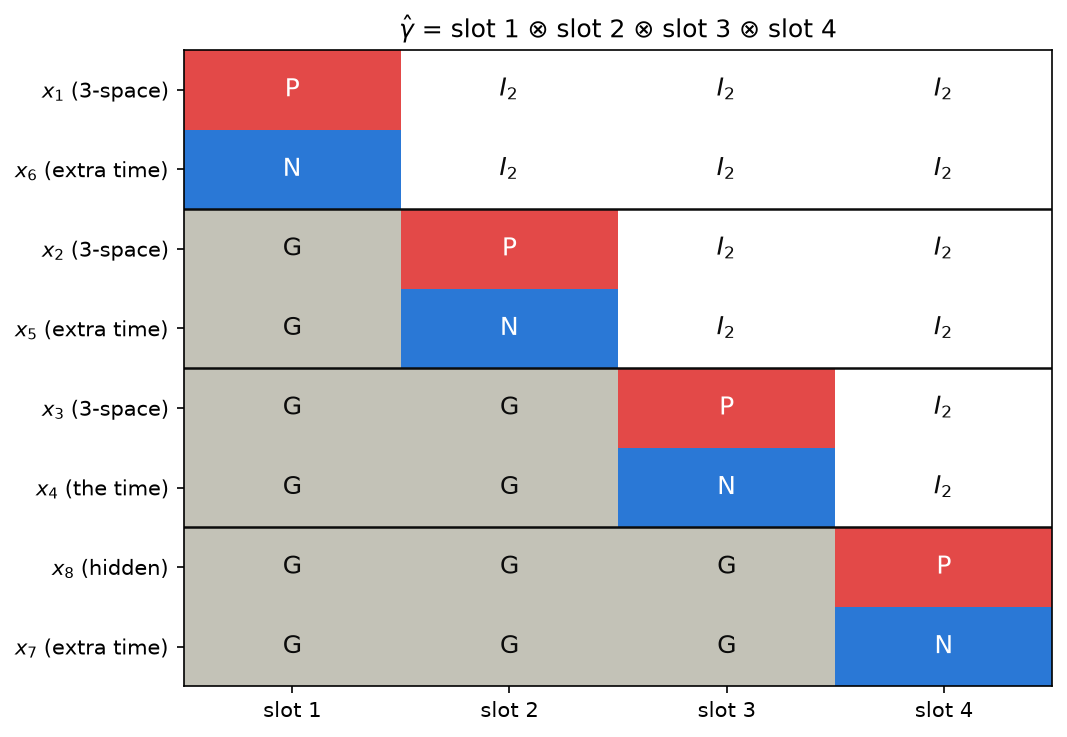

Figure 04d.1 saved as Revision/textbook/figures/04d_1_slot_pattern.png


In [5]:
PAIR_ORDER = [0, 5, 1, 4, 2, 3, 7, 6]  # x1, x6, x2, x5, x3, x4, x8, x7
ROLE = ["3-space", "3-space", "3-space", "the time", "extra time", "extra time",
        "extra time", "hidden"]
CODE = {"I": 0, "G": 1, "P": 2, "N": 3}  # a number per letter, for the colours
grid = np.array([[CODE[name] for name in FACTORS[a]] for a in PAIR_ORDER])
slot_colours = ListedColormap(["#ffffff", "#c3c2b7", "#e34948", "#2a78d6"])
fig, ax = plt.subplots(figsize=(7.0, 4.8), layout="constrained")
# aspect="auto": the squares become rectangles that fill the panel
ax.imshow(grid, cmap=slot_colours, norm=BoundaryNorm([-0.5, 0.5, 1.5, 2.5, 3.5], 4),
          aspect="auto")
for row, a in enumerate(PAIR_ORDER):
    for column, name in enumerate(FACTORS[a]):
        text = "$I_2$" if name == "I" else name
        colour = "white" if name in ("P", "N") else "#0b0b0b"
        ax.text(column, row, text, ha="center", va="center", fontsize=12,
                color=colour)
ax.set_xticks(range(4), [f"slot {k}" for k in range(1, 5)])
ax.set_yticks(range(8), [f"$x_{a + 1}$ ({ROLE[a]})" for a in PAIR_ORDER])
for boundary in (1.5, 3.5, 5.5):  # lines between the four pairs
    ax.axhline(boundary, color="#0b0b0b", linewidth=1.2)
ax.grid(False)
ax.set_title("$\\hat\\gamma$ = slot 1 $\\otimes$ slot 2 $\\otimes$ slot 3 "
             "$\\otimes$ slot 4")
save_figure(fig, "slot_pattern",
            "The recipe of the tensor-product gammas: row $x_a$ shows the four "
            "$2 \\times 2$ factors of $\\hat\\gamma^{(x_a)}$, slot 1 on the left "
            "(G grey, P red, N blue, $I_2$ white). The rows are grouped in the pairs "
            "that share a slot, one space-like direction (P) and one time-like "
            "direction (N) each: ($x_1$, $x_6$), ($x_2$, $x_5$), ($x_3$, $x_4$), "
            "($x_8$, $x_7$). Every matrix has G before its own slot and $I_2$ after "
            "it, the staircase that makes all eight anticommute.")

The next cell draws the eight hat gammas as heat maps (blue $-1$, light grey 0,
red $+1$; rows and columns numbered 0 to 15), in the order $x_1, \dots, x_8$.

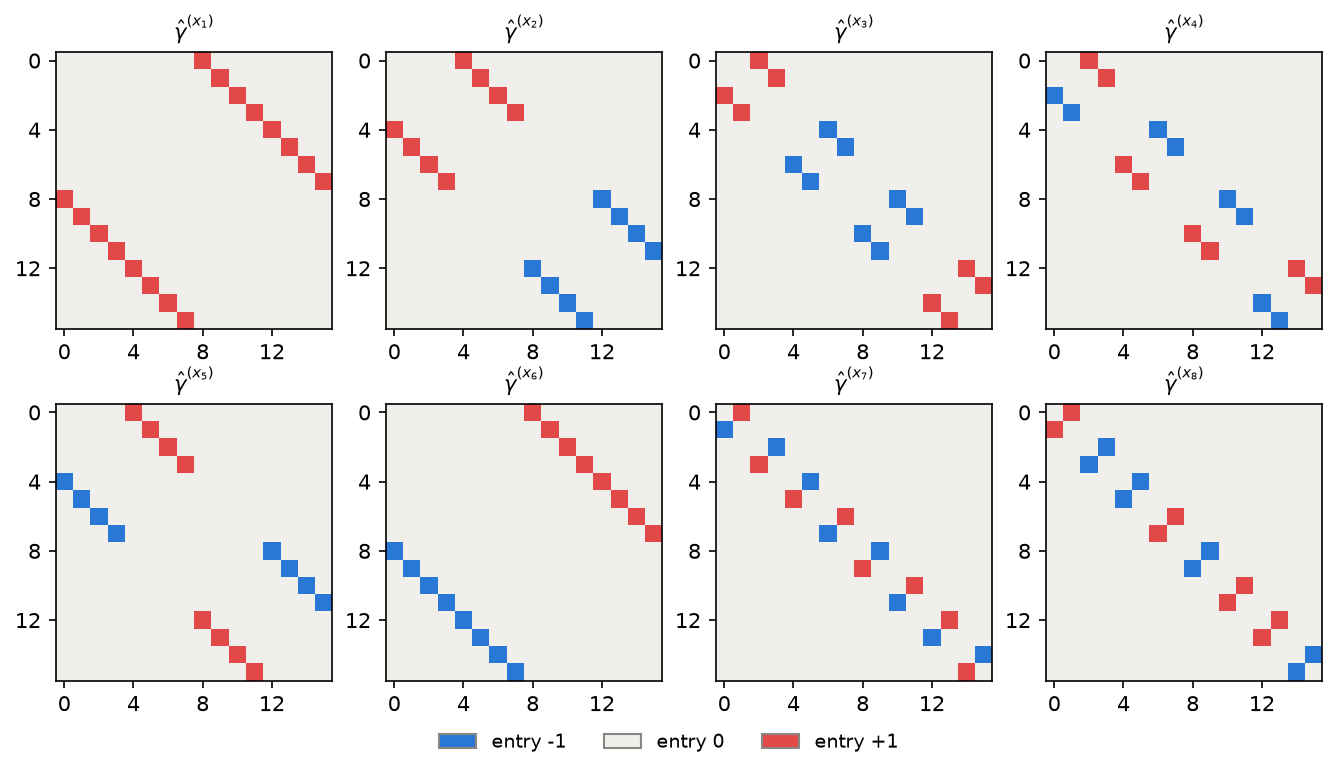

Figure 04d.2 saved as Revision/textbook/figures/04d_2_tensor_gammas.png


In [6]:
SIGN_COLOURS = ListedColormap(["#2a78d6", "#f0efec", "#e34948"])  # -1, 0, +1
SIGN_NORM = BoundaryNorm([-1.5, -0.5, 0.5, 1.5], SIGN_COLOURS.N)


def draw_signs(ax, matrix, title):
    """Draw a matrix with entries -1, 0, +1 as a heat map in the panel ax."""
    ax.imshow(matrix, cmap=SIGN_COLOURS, norm=SIGN_NORM)
    ax.set_title(title, fontsize=10)
    ax.set_xticks(range(0, 16, 4))
    ax.set_yticks(range(0, 16, 4))
    ax.grid(False)  # no grid lines on top of the coloured squares


def sign_legend(fig):
    """The key of the three colours, below the panels of the figure."""
    handles = [Patch(facecolor=SIGN_COLOURS(k), edgecolor="#898781", label=label)
               for k, label in enumerate(["entry -1", "entry 0", "entry +1"])]
    fig.legend(handles=handles, loc="outside lower center", ncol=3, fontsize=9,
               frameon=False)


fig, axes = plt.subplots(2, 4, figsize=(8.8, 5.0), layout="constrained")
for a in range(8):  # a // 4 is the row of the panel, a % 4 its column
    draw_signs(axes[a // 4, a % 4], hat[a], f"$\\hat\\gamma^{{(x_{a + 1})}}$")
sign_legend(fig)
save_figure(fig, "tensor_gammas",
            "The eight tensor-product gammas $\\hat\\gamma^{(x_1)}$ to "
            "$\\hat\\gamma^{(x_8)}$ (rows and columns numbered 0 to 15; blue $-1$, "
            "grey 0, red $+1$). Each is a signed permutation matrix, like the "
            "author's, but the pattern is different: a factor P or N in slot $k$ "
            "exchanges components whose numbers differ in bit $k$, so the nonzero "
            "entries lie on diagonals at distance 8, 4, 2 or 1 from the main "
            "diagonal, and the factors G in front flip signs.")

## 8. The Clifford relation and the 256 products

The next cell checks exactly, for the hat gammas: the Clifford relation for all 64
ordered pairs (each anticommutator is $2\eta^{ab} I_{16}$); that every hat gamma is a
signed permutation matrix; and that it has the author's symmetry pattern
$(\hat\gamma^{(x_a)})^T = \eta_{aa}\hat\gamma^{(x_a)}$ (symmetric for
$x_1, x_2, x_3, x_8$, antisymmetric for $x_4, \dots, x_7$; P, G and $I_2$ are
symmetric and N antisymmetric, so this follows from $(A \otimes B)^T = A^T \otimes
B^T$). Then it forms the 256 ordered products of BOTH sets (sets of directions in
increasing order, as `itertools.combinations` lists them) and computes the exact
rank of the 256 hat products, each written as a row of 256 numbers.

In [7]:
clifford_ok = all(
    (hat[a] @ hat[b] + hat[b] @ hat[a] == 2 * eta[a] * (a == b) * I16).all()
    for a in range(8) for b in range(8))  # (a == b) is 1 or 0
permutation_ok = all((np.count_nonzero(m, axis=0) == 1).all()
                     and (np.count_nonzero(m, axis=1) == 1).all()
                     and (np.abs(m).sum() == 16) for m in hat)
symmetry_ok = all((hat[a].T == eta[a] * hat[a]).all() for a in range(8))
check(clifford_ok and permutation_ok and symmetry_ok,
      "hat gammas: {hat g^a, hat g^b} = 2 eta^ab I16 (64 pairs), signed "
      "permutations, (hat g^a)^T = eta_aa hat g^a")

SETS = [s for k in range(9) for s in itertools.combinations(range(8), k)]


def product(matrices, indices):
    """The product of matrices[i] for i in indices, from left to right."""
    result = I16
    for i in indices:
        result = result @ matrices[i]
    return result


author_products = np.array([product(gamma, s) for s in SETS])  # gamma_A, 256 of them
hat_products = np.array([product(hat, s) for s in SETS])  # hat gamma_A


def exact_rank(rows):
    """The exact rank of a list of rows of whole numbers (fractions, over QQ)."""
    matrix = DomainMatrix([[sp.ZZ(int(x)) for x in row] for row in rows],
                          (len(rows), len(rows[0])), sp.ZZ)
    return matrix.convert_to(sp.QQ).rank()


hat_rank = exact_rank(hat_products.reshape(256, 256).tolist())
report("exact rank of the 256 products of the hat gammas", hat_rank)
check(hat_rank == 256, "the 256 hat products are a basis of all real 16 x 16 matrices")

PASS hat gammas: {hat g^a, hat g^b} = 2 eta^ab I16 (64 pairs), signed permutations, (hat
    g^a)^T = eta_aa hat g^a
RESULT exact rank of the 256 products of the hat gammas = 256
PASS the 256 hat products are a basis of all real 16 x 16 matrices


## 9. The chirality product in both pictures

For the hat gammas the product of all eight can be found by hand. First the product
of the two matrices of one slot $k$: slot by slot, $G \cdot G = I_2$ before $k$,
$PN = -G$ in slot $k$, and $I_2$ after $k$; so it is $-(G$ in slot $k$, $I_2$
elsewhere$)$. Second, the chirality product $\hat\Gamma$ takes the factors in the
author's order $x_8, x_1, x_2, \dots, x_7$; reordering them into the pairs
$(x_1, x_6), (x_2, x_5), (x_3, x_4), (x_8, x_7)$ exchanges neighbours that
anticommute, so it multiplies the product by the *permutation sign* of the
reordering: $+1$ if the number of *inversions* (pairs of factors whose order is
reversed) is even and $-1$ if it is odd, because each exchange of two neighbours
gives a factor $-1$ and changes the number of inversions by one.
Third, the four pair products give
$(-1)^4\, G \otimes G \otimes G \otimes G$ (each slot receives one G). Its diagonal
entry in row $j = 8b_1 + 4b_2 + 2b_3 + b_4$ is $(-1)^{b_1 + b_2 + b_3 + b_4}$,
because $G = \mathrm{diag}(+1, -1)$ contributes $-1$ for every bit equal to 1.

The next cell checks the pair products, computes the permutation sign of the
reordering, checks $\hat\Gamma = $ sign $\times\, G \otimes G \otimes G \otimes G$,
and compares with the author's chirality product
$\Gamma = \mathrm{diag}(-I_8, I_8)$, which the Revision record checked. `format(j,
"04b")` writes the number $j$ with four binary digits.

In [8]:
WOLFRAM = "Revision/algebra/reports/wolfram-algebra.json"
PYTHON = "Revision/algebra/reports/python-algebra.json"
RECORDED = {}  # report file -> {check name: the check (name, verdict, detail)}
for report_file in (WOLFRAM, PYTHON):
    text = repository_file(report_file).read_text(encoding="utf-8")
    RECORDED[report_file] = {e["name"]: e for e in json.loads(text)["checks"]}


def check_record(condition, name, *records):
    """check(condition, name) for a statement that the Revision record verified;
    records are pairs (report file, check name), each recorded as passed."""
    for report_file, check_name in records:
        entry = RECORDED[report_file].get(check_name)
        if entry is None or entry["verdict"].upper() != "PASS":
            raise AssertionError(f"{report_file} has no passed check {check_name}")
    check(condition, name)
    for report_file, check_name in records:
        print(f"     reproduces {report_file}")
        print(f"         check {check_name}")


def permutation_sign(numbers):
    """+1 for an even, -1 for an odd number of inversions (pairs i < j with
    numbers[i] > numbers[j])."""
    inversions = sum(1 for i, j in itertools.combinations(range(len(numbers)), 2)
                     if numbers[i] > numbers[j])
    return -1 if inversions % 2 else 1


PAIRS = [(0, 5), (1, 4), (2, 3), (7, 6)]  # (x1,x6) (x2,x5) (x3,x4) (x8,x7)
pair_ok = True
for slot, (s, t) in enumerate(PAIRS, start=1):
    only_g = kron4(*[G if k == slot else I2 for k in range(1, 5)])
    pair_ok &= bool((hat[s] @ hat[t] == -only_g).all())
AUTHOR_ORDER = [7, 0, 1, 2, 3, 4, 5, 6]  # x8, x1, x2, ..., x7
paired_order = [a for pair in PAIRS for a in pair]  # x1, x6, x2, x5, x3, x4, x8, x7
# where each factor of the paired order stands in the author's order
positions = [AUTHOR_ORDER.index(a) for a in paired_order]
reorder_sign = permutation_sign(positions)
say(f"positions of x1, x6, x2, x5, x3, x4, x8, x7 in the author's order: "
    f"{positions}; permutation sign {reorder_sign:+d}")
chirality_hat = product(hat, AUTHOR_ORDER)
gggg = kron4(G, G, G, G)
bits = [format(j, "04b") for j in range(16)]  # "0000", "0001", ..., "1111"
parity = [(-1) ** b.count("1") for b in bits]  # -1 for an odd number of 1s
check(pair_ok and (chirality_hat == reorder_sign * gggg).all()
      and (np.diag(chirality_hat) == parity).all()
      and (chirality_hat == np.diag(parity)).all(),
      "hat Gamma = (sign +1) G (x) G (x) G (x) G = diag((-1)^(b1+b2+b3+b4))")
chirality_author = product(gamma, AUTHOR_ORDER)
say("rows with -1 on the diagonal, author: "
    f"{[j for j in range(16) if chirality_author[j, j] < 0]}")
say("rows with -1 on the diagonal, hat:    "
    f"{[j for j in range(16) if chirality_hat[j, j] < 0]}")
check_record((chirality_author == np.diag([-1] * 8 + [1] * 8)).all(),
             "author: Gamma = gamma^(x8) gamma^(x1) ... gamma^(x7) = diag(-I8, I8)",
             (WOLFRAM, "Gamma_diag"), (PYTHON, "chirality_diag"))

positions of x1, x6, x2, x5, x3, x4, x8, x7 in the author's order: [1, 6, 2, 5, 3, 4, 0,
    7]; permutation sign +1
PASS hat Gamma = (sign +1) G (x) G (x) G (x) G = diag((-1)^(b1+b2+b3+b4))
rows with -1 on the diagonal, author: [0, 1, 2, 3, 4, 5, 6, 7]
rows with -1 on the diagonal, hat:    [1, 2, 4, 7, 8, 11, 13, 14]
PASS author: Gamma = gamma^(x8) gamma^(x1) ... gamma^(x7) = diag(-I8, I8)
     reproduces Revision/algebra/reports/wolfram-algebra.json
         check Gamma_diag
     reproduces Revision/algebra/reports/python-algebra.json
         check chirality_diag


The next cell draws the two diagonals: on top the author's $\Gamma$ (eight $-1$, then
eight $+1$), below the hat $\hat\Gamma$, whose sign follows the parity of the bits of
the row number (the bits are written under the axis).

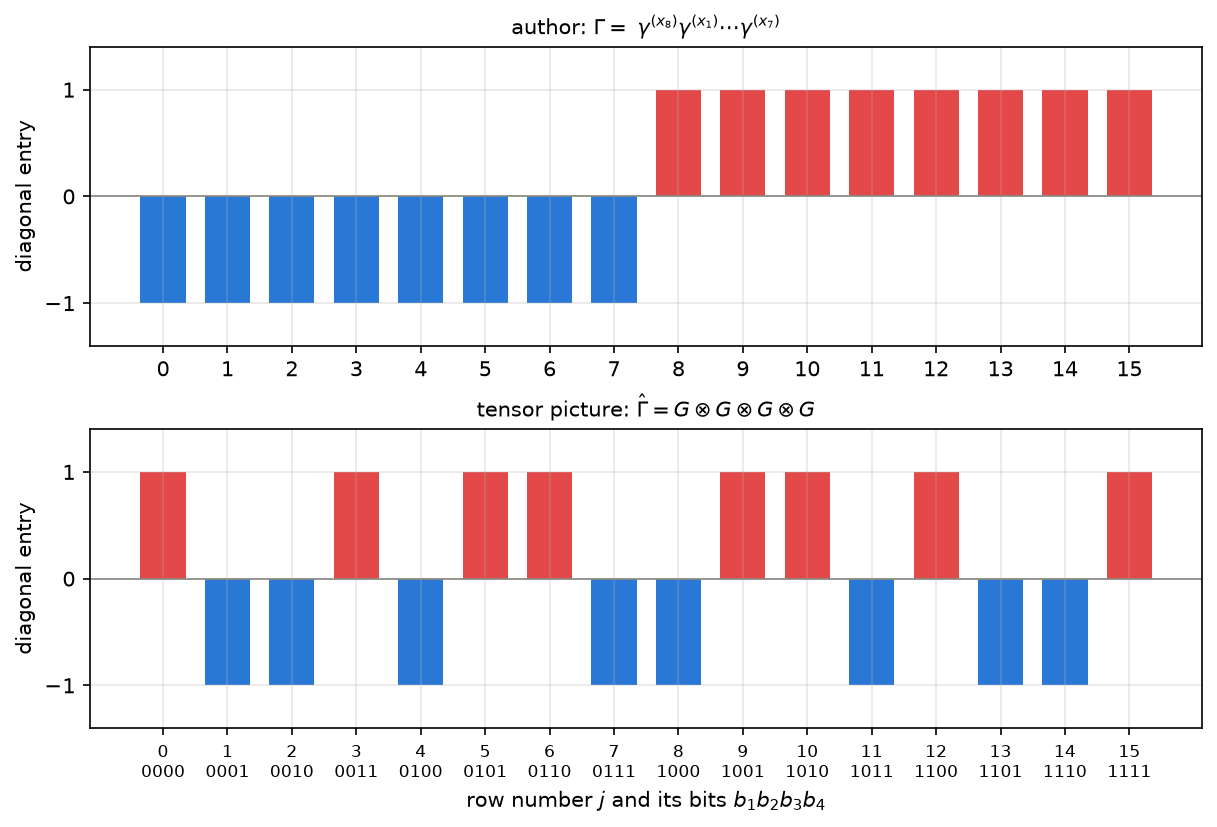

Figure 04d.3 saved as Revision/textbook/figures/04d_3_chirality_diagonals.png


In [9]:
fig, (top, bottom) = plt.subplots(2, 1, figsize=(8.0, 5.4), layout="constrained")
for ax, values, title in (
        (top, np.diag(chirality_author), "author: $\\Gamma = $ "
         "$\\gamma^{(x_8)}\\gamma^{(x_1)}\\cdots\\gamma^{(x_7)}$"),
        (bottom, np.diag(chirality_hat), "tensor picture: $\\hat\\Gamma = "
         "G \\otimes G \\otimes G \\otimes G$")):
    colours = ["#2a78d6" if v < 0 else "#e34948" for v in values]
    ax.bar(range(16), values, color=colours, width=0.7)
    ax.axhline(0.0, color="#898781", linewidth=0.8)
    ax.set_ylim(-1.4, 1.4)
    ax.set_yticks([-1, 0, 1])
    ax.set_ylabel("diagonal entry")
    ax.set_title(title, fontsize=10)
top.set_xticks(range(16))
bottom.set_xticks(range(16), [f"{j}\n{bits[j]}" for j in range(16)], fontsize=8)
bottom.set_xlabel("row number $j$ and its bits $b_1 b_2 b_3 b_4$")
save_figure(fig, "chirality_diagonals",
            "The chirality product in the two pictures; both are diagonal matrices, "
            "and the bars show their 16 diagonal entries (horizontal axis the row "
            "number $j$ from 0 to 15, blue $-1$, red $+1$). Top: the author's "
            "$\\Gamma$ has $-1$ in rows 0 to 7 and $+1$ in rows 8 to 15. Bottom: the "
            "tensor-product $\\hat\\Gamma = G \\otimes G \\otimes G \\otimes G$ has "
            "$(-1)$ to the power $b_1 + b_2 + b_3 + b_4$, $-1$ exactly in the rows "
            "1, 2, 4, 7, 8, 11, 13, 14 whose bits contain an odd number of ones. "
            "Both have eight entries of each sign; the change of basis of the next "
            "figure moves the eight rows with $-1$ to the top.")

## 10. The change of basis

The next cell computes $S = \sum_A \gamma_A M \hat\gamma_A^T$ for the simplest
choices $M = E_{ij}$. The term $\gamma_A E_{ij} \hat\gamma_A^T$ has the entry
$(\gamma_A)_{ki} (\hat\gamma_A)_{lj}$ in row $k$, column $l$ (only column $i$ of
$\gamma_A$ and column $j$ of $\hat\gamma_A$ survive), so the whole sum over the 256
sets is ONE matrix product: the $16 \times 256$ table of the columns $i$ of all
$\gamma_A$ times the $256 \times 16$ table of the columns $j$ of all $\hat\gamma_A$.
The cell confirms this shortcut against the plain sum for the first nonzero $S$,
which it finds by trying $(i, j) = (0, 0), (0, 1), \dots$ in order. Then it checks,
exactly: $\gamma^{(x_a)} S = S \hat\gamma^{(x_a)}$ for all eight directions,
$S^T S = c I_{16}$, and that $Q = S/\sqrt{c}$ is a signed permutation matrix. It
prints $Q$ in a short code notation: for each row the column and the sign of its
single nonzero entry, so "+8" in row 0 means $(Qu)_0 = +u_8$ for every column $u$.

In [10]:
def change_of_basis(products_1, products_2, i, j):
    """S = sum_A products_1[A] E_ij products_2[A]^T as one matrix product:
    products_1[:, :, i] is the table of the columns i (256 rows of 16 numbers)."""
    return products_1[:, :, i].T @ products_2[:, :, j]


def first_nonzero(products_1, products_2):
    """The first (i, j) in reading order with a nonzero S, and that S."""
    for i, j in itertools.product(range(16), repeat=2):
        S = change_of_basis(products_1, products_2, i, j)
        if S.any():
            return i, j, S
    raise ValueError("every S is zero")


i0, j0, S = first_nonzero(author_products, hat_products)
E = np.zeros((16, 16), dtype=np.int64)
E[i0, j0] = 1  # the matrix E_ij with a single 1
plain_sum = sum(author_products[t] @ E @ hat_products[t].T for t in range(256))
report("first (i, j) with a nonzero S", (i0, j0))
report("the different entries of S", sorted(set(int(x) for x in S.flatten())))
c = int((S.T @ S)[0, 0])  # the factor c in S^T S = c I16
root = int(round(c ** 0.5))  # its square root, a whole number here
report("c in S^T S = c I16, and its square root", (c, root))
check((plain_sum == S).all()
      and all((gamma[a] @ S == S @ hat[a]).all() for a in range(8))
      and (S.T @ S == c * I16).all() and root * root == c,
      "S intertwines: gamma^a S = S hat gamma^a for all 8 a, and S^T S = c I16")
Q = S // root  # exact: every entry of S is a multiple of root
codes = []
for row in Q:
    column = int(np.flatnonzero(row)[0])  # the column of the nonzero entry
    codes.append(("+" if row[column] > 0 else "-") + str(column))
say("rows 0 to 15 of Q: " + " ".join(codes))
check((Q * root == S).all() and (np.count_nonzero(Q, axis=0) == 1).all()
      and (np.count_nonzero(Q, axis=1) == 1).all() and (Q.T @ Q == I16).all(),
      "Q = S / sqrt(c) is a signed permutation matrix (orthogonal)")

RESULT first (i, j) with a nonzero S = (0, 8)
RESULT the different entries of S = [-16, 0, 16]
RESULT c in S^T S = c I16, and its square root = (256, 16)
PASS S intertwines: gamma^a S = S hat gamma^a for all 8 a, and S^T S = c I16
rows 0 to 15 of Q: +8 +4 +2 -14 -7 +11 -13 -1 -9 -5 -3 +15 -6 +10 -12 -0
PASS Q = S / sqrt(c) is a signed permutation matrix (orthogonal)


The next cell checks the full statement: not only the eight gammas but all 256
products and the chirality product transform with $Q$,
$\gamma_A = Q\hat\gamma_A Q^T$ and $\Gamma = Q\hat\Gamma Q^T$. It also checks a
formula that explains which $E_{ij}$ give a nonzero $S$: for every $i, j$,
$S(E_{ij}) = 16\,Q_{ij}\,Q$. (Reason: $\sum_A \hat\gamma_A Y \hat\gamma_A^T$ commutes
with every hat gamma by the argument of the situation section, so it is a multiple
of $I_{16}$; its trace is $\sum_A \mathrm{tr}\,Y = 256\,\mathrm{tr}\,Y$, so it is
$16\,\mathrm{tr}(Y) I_{16}$; with $\gamma_A = Q\hat\gamma_A Q^T$ and $Y = Q^T E_{ij}$
this gives $S(E_{ij}) = Q \cdot 16\,\mathrm{tr}(Q^T E_{ij}) = 16\,Q_{ij}\,Q$.) So $S$
is nonzero exactly for the 16 positions $(i, j)$ where $Q$ has its nonzero entries,
and the first of them is the one found above.

In [11]:
all_products_ok = all((author_products[t] == Q @ hat_products[t] @ Q.T).all()
                      for t in range(256))
check(all_products_ok and (chirality_author == Q @ chirality_hat @ Q.T).all(),
      "gamma_A = Q hat gamma_A Q^T for all 256 products, and Gamma = Q hat Gamma Q^T")
formula_ok = all((change_of_basis(author_products, hat_products, i, j)
                  == 16 * Q[i, j] * Q).all()
                 for i, j in itertools.product(range(16), repeat=2))
nonzero_positions = int(np.count_nonzero(Q))
report("positions (i, j) with a nonzero S(E_ij)", nonzero_positions)
check(formula_ok and nonzero_positions == 16,
      "S(E_ij) = 16 Q_ij Q for all 256 positions (i, j)")

PASS gamma_A = Q hat gamma_A Q^T for all 256 products, and Gamma = Q hat Gamma Q^T
RESULT positions (i, j) with a nonzero S(E_ij) = 16
PASS S(E_ij) = 16 Q_ij Q for all 256 positions (i, j)


The next cell draws $Q$ as a heat map: row $i$ is a component of the author's basis,
column $j$ a component of the tensor basis, and the single nonzero entry of row $i$
says which tensor component, with which sign, becomes author component $i$.

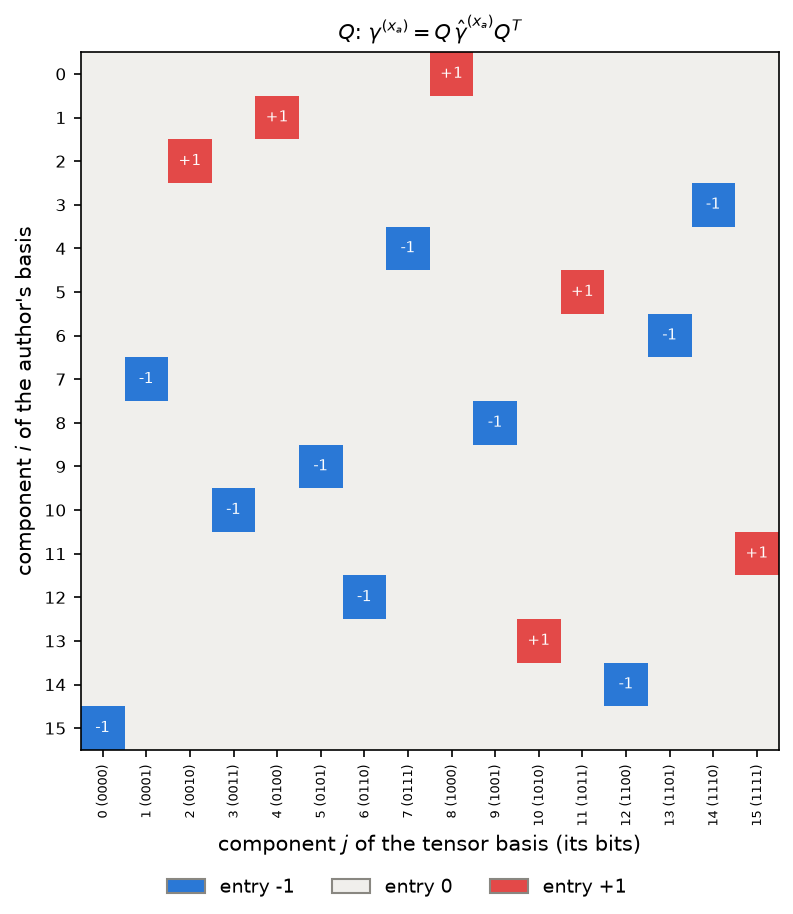

Figure 04d.4 saved as Revision/textbook/figures/04d_4_change_of_basis.png


In [12]:
fig, ax = plt.subplots(figsize=(6.0, 6.0), layout="constrained")
draw_signs(ax, Q, "$Q$: $\\gamma^{(x_a)} = Q\\,\\hat\\gamma^{(x_a)} Q^T$")
ax.set_xticks(range(16), [f"{j} ({bits[j]})" for j in range(16)], fontsize=6,
              rotation=90)
ax.set_yticks(range(16), [str(i) for i in range(16)], fontsize=8)
ax.set_xlabel("component $j$ of the tensor basis (its bits)")
ax.set_ylabel("component $i$ of the author's basis")
for i in range(16):
    j = int(np.flatnonzero(Q[i])[0])
    ax.text(j, i, f"{Q[i, j]:+d}", ha="center", va="center", color="white",
            fontsize=7)
sign_legend(fig)
save_figure(fig, "change_of_basis",
            "The change of basis $Q$ from the tensor-product gammas to the author's "
            "gammas, $\\gamma^{(x_a)} = Q\\hat\\gamma^{(x_a)}Q^T$ for all eight "
            "directions (rows: the author's components 0 to 15; columns: the tensor "
            "components 0 to 15 with their bits; blue $-1$, red $+1$). $Q$ is a "
            "signed permutation: every row and column holds one entry $\\pm 1$, so "
            "the author's matrices are the tensor-product matrices with the 16 "
            "components renumbered and some signs flipped. The first eight rows "
            "pick the eight tensor components with an odd number of ones in their "
            "bits, the rows where $\\hat\\Gamma = -1$.")

## 11. Only one change of basis

The situation section proved that every intertwiner is a multiple of $Q$. The next
cell checks it directly. The equations $\gamma^{(x_a)} X - X\hat\gamma^{(x_a)} = 0$
for the 256 entries of $X$ (read row by row: entry $(k, l)$ is unknown number
$16k + l$) form a system of $8 \times 256 = 2048$ equations; with this numbering
$LX$ becomes $(L \otimes I_{16})$ times the list of unknowns and $XR$ becomes
$(I_{16} \otimes R^T)$ times it (write out both products entry by entry). The cell
computes the exact rank of the system: 255, so the solutions form a space of
dimension $256 - 255 = 1$, the multiples of $Q$. It does the same for the
equations $\gamma^{(x_a)} X - X\gamma^{(x_a)} = 0$, the matrices that commute with
all eight of the author's gammas: dimension 1 again (the multiples of $I_{16}$), the
number that the Revision record found with two independent programs.

In [13]:
def intertwiner_system(left, right):
    """The 2048 x 256 matrix of the equations left[a] X - X right[a] = 0, a = 1..8,
    for the 256 entries of X read row by row."""
    return np.vstack([np.kron(left[a], I16) - np.kron(I16, right[a].T)
                      for a in range(8)])


system = intertwiner_system(gamma, hat)  # the author's gammas and the hat gammas
commutant = intertwiner_system(gamma, gamma)  # the author's gammas on both sides
rank_system, rank_commutant = exact_rank(system.tolist()), exact_rank(
    commutant.tolist())
report("exact ranks of the two systems (2048 equations, 256 unknowns)",
       (rank_system, rank_commutant))
q_solves = not (system @ Q.reshape(256)).any()  # Q, read row by row, solves it
check(rank_system == 255 and q_solves,
      "the intertwiners form a space of dimension 1: the multiples of Q")
python_detail = RECORDED[PYTHON]["pin_commutant_dimension_1"]["detail"]
wolfram_detail = RECORDED[WOLFRAM]["Pin44_irreducible_commutant_dim_1"]["detail"]
check_record(256 - rank_commutant == 1 and not (commutant @ I16.reshape(256)).any()
             and "= 1 (Fraction), 1 (sympy)" in python_detail
             and "has dimension 1" in wolfram_detail,
             "only the multiples of I16 commute with all eight author's gammas",
             (PYTHON, "pin_commutant_dimension_1"),
             (WOLFRAM, "Pin44_irreducible_commutant_dim_1"))

RESULT exact ranks of the two systems (2048 equations, 256 unknowns) = (255, 255)
PASS the intertwiners form a space of dimension 1: the multiples of Q
PASS only the multiples of I16 commute with all eight author's gammas
     reproduces Revision/algebra/reports/python-algebra.json
         check pin_commutant_dimension_1
     reproduces Revision/algebra/reports/wolfram-algebra.json
         check Pin44_irreducible_commutant_dim_1


**How strongly the equations reject every other matrix.** Square the left-hand
sides and add them up: for a matrix $X$ (as a list $v$ of 256 numbers) the sum of
the squares of all 2048 equations is $v^T K v$ with the $256 \times 256$ matrix
$K = A^T A$, where $A$ is the system. $K$ has a complete set of exact eigenvectors:
the matrices $X_B = Q\hat\gamma_B$ for the 256 sets $B$. Indeed
$\gamma^{(a)} X_B - X_B\hat\gamma^{(a)} = Q(\hat\gamma^{(a)}\hat\gamma_B -
\hat\gamma_B\hat\gamma^{(a)})$, and by the rule for passing one gamma through a
product (a product of $k$ gammas) this is 0 when $\hat\gamma^{(a)}$ commutes with
$\hat\gamma_B$ and $2Q\hat\gamma^{(a)}\hat\gamma_B$ when it anticommutes. The
anticommuting directions are the $k$ directions in $B$ for an even $k$, and the
$8 - k$ directions outside $B$ for an odd $k$. So $K v_B = 4\,n_B\,v_B$ with
$n_B = k$ (even $k$) or $8 - k$ (odd $k$): the eigenvalues are
$0, 4, 8, \dots, 32$ with the multiplicities $\binom{8}{0}, \binom{8}{1}, \dots,
\binom{8}{8}$, and the eigenvalue 0 belongs only to $B = \{\}$, that is to $Q$. The
next cell checks $K v_B = 4 n_B v_B$ exactly for all 256 sets, counts the
multiplicities, and confirms them with numpy's floating-point eigenvalues (rounded to
whole numbers).

In [14]:
K = system.T @ system  # 256 x 256, whole numbers
penalty = []  # 4 n_B for every set B
eigen_ok = True
for t, s in enumerate(SETS):
    k = len(s)
    n_B = k if k % 2 == 0 else 8 - k  # the number of anticommuting directions
    v = (Q @ hat_products[t]).reshape(256)  # X_B = Q hat gamma_B, row by row
    eigen_ok &= bool((K @ v == 4 * n_B * v).all())
    penalty.append(4 * n_B)
values = list(range(0, 33, 4))  # 0, 4, ..., 32
multiplicities = [penalty.count(v) for v in values]
numeric = np.linalg.eigvalsh(K.astype(float))  # floating-point eigenvalues
rounded = np.round(numeric).astype(int)  # nearest whole numbers
numeric_ok = np.max(np.abs(numeric - rounded)) < 1e-9 and all(
    int(np.sum(rounded == v)) == m for v, m in zip(values, multiplicities))
report("eigenvalues 0, 4, ..., 32 of K have the multiplicities", multiplicities)
check(eigen_ok and multiplicities == [comb(8, j) for j in range(9)] and numeric_ok,
      "K = A^T A has the exact eigenvalues 4 n_B; only Q has the eigenvalue 0")

RESULT eigenvalues 0, 4, ..., 32 of K have the multiplicities = [1, 8, 28, 56, 70, 56,
    28, 8, 1]
PASS K = A^T A has the exact eigenvalues 4 n_B; only Q has the eigenvalue 0


The next cell draws the multiplicities as bars.

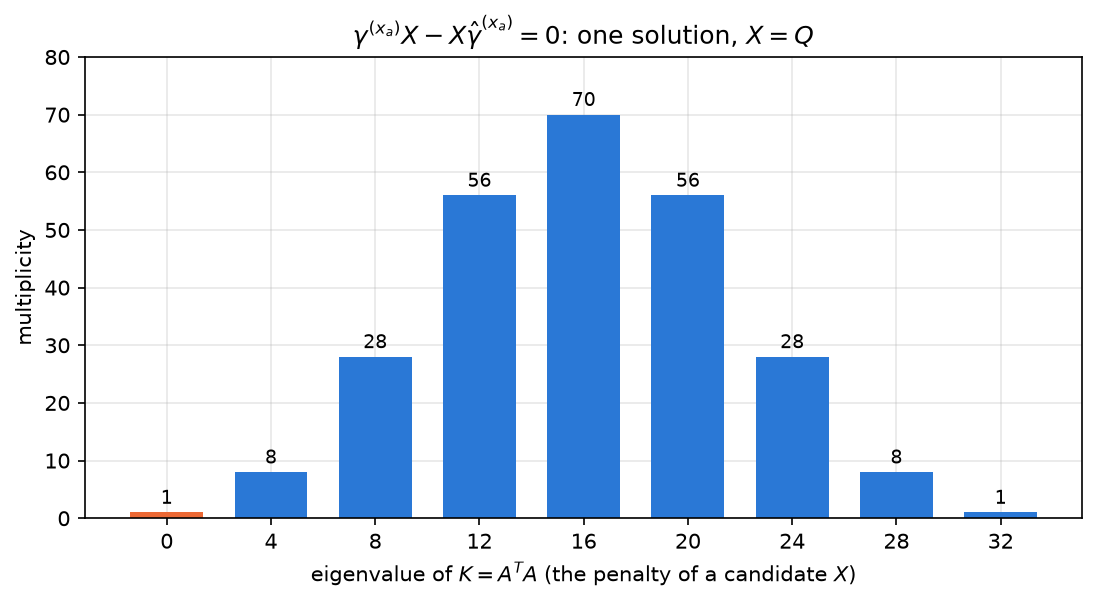

Figure 04d.5 saved as Revision/textbook/figures/04d_5_penalty_spectrum.png


In [15]:
fig, ax = plt.subplots(figsize=(7.2, 3.9), layout="constrained")
ax.set_axisbelow(True)  # grid lines behind the bars
colours = ["#eb6834" if v == 0 else "#2a78d6" for v in values]
bars = ax.bar(values, multiplicities, width=2.8, color=colours)
ax.bar_label(bars, labels=[str(m) for m in multiplicities], padding=2, fontsize=9)
ax.set_xticks(values)
ax.set_ylim(0, 80)
ax.set_xlabel("eigenvalue of $K = A^T A$ (the penalty of a candidate $X$)")
ax.set_ylabel("multiplicity")
ax.set_title("$\\gamma^{(x_a)}X - X\\hat\\gamma^{(x_a)} = 0$: one solution, $X = Q$")
save_figure(fig, "penalty_spectrum",
            "How the 2048 equations $\\gamma^{(x_a)}X - X\\hat\\gamma^{(x_a)} = 0$ "
            "judge every $16 \\times 16$ matrix $X$: the eigenvalues of the matrix "
            "$K = A^T A$ (horizontal axis; the sum of the squared equations is the "
            "eigenvalue times the squared size of $X$ for an eigenvector $X$) and "
            "how many independent eigenvectors belong to each (vertical axis). The "
            "eigenvectors are the matrices $Q\\hat\\gamma_B$ for the 256 sets $B$ of "
            "directions, with eigenvalue 4 times the number of directions whose "
            "gamma anticommutes with $\\hat\\gamma_B$; the multiplicities are the "
            "binomial coefficients 1, 8, 28, 56, 70, 56, 28, 8, 1. Only one matrix, "
            "$Q$ itself (orange), has the eigenvalue 0: the change of basis is "
            "unique up to a factor.")

## 12. Another way to fill the slots

Any assignment of the eight directions to the slots works for the Clifford
relation, as long as every slot gets one P and one N. Take the simpler-looking one:
$x_1, x_2, x_3$ in slots 1, 2, 3 with P, $x_4, x_5, x_6$ in slots 1, 2, 3 with N,
and $x_8$ (P) and $x_7$ (N) in slot 4. The pairs are now (x1, x4), (x2, x5),
(x3, x6) and (x8, x7). By the theorem a change of basis must exist again. Is it a
signed permutation?

A signed permutation $Q$ turns a diagonal matrix $D$ into a diagonal matrix
$QDQ^T$ (it only renumbers the diagonal entries and multiplies each by
$(\pm 1)^2 = 1$). So if $\gamma_A = Q\hat\gamma_A Q^T$ with a signed permutation $Q$,
then $\gamma_A$ is diagonal exactly when $\hat\gamma_A$ is: the two sets must have
their diagonal products for the SAME sets $A$. The next cell lists these sets. For
the author's gammas they are the 16 sets made of whole pairs (x1, x6), (x2, x5),
(x3, x4), (x8, x7) (the products of the two matrices of one pair are diagonal, as
section 9 showed for the hat gammas); the first assignment has the same pairs, the
second has different ones. The cell then builds the second set, checks its Clifford
relation, and computes its change of basis $S_2$ with the same formula: $S_2^T S_2 =
128\,I_{16}$, and every row of $S_2$ has two nonzero entries $\pm 8$, so
$Q_2 = S_2/\sqrt{128}$ has the entries $\pm 8/\sqrt{128} = \pm 1/\sqrt2$: an
orthogonal matrix that mixes the components in pairs, not a signed permutation.

In [16]:
SLOT_2 = [1, 2, 3, 1, 2, 3, 4, 4]  # pairs (x1,x4) (x2,x5) (x3,x6) (x8,x7)
FACTORS_2 = [factor_names(SLOT_2[a], "P" if eta[a] > 0 else "N") for a in range(8)]
hat_2 = [kron4(*[MATRIX_OF[name] for name in FACTORS_2[a]]) for a in range(8)]
clifford_2 = all(
    (hat_2[a] @ hat_2[b] + hat_2[b] @ hat_2[a] == 2 * eta[a] * (a == b) * I16).all()
    for a in range(8) for b in range(8))
check(clifford_2 and all((hat_2[a].T == eta[a] * hat_2[a]).all() for a in range(8)),
      "second assignment: the Clifford relation and the symmetry pattern hold too")
hat_2_products = np.array([product(hat_2, s) for s in SETS])


def diagonal_sets(products):
    """The sets A (as coordinate names) whose product is a diagonal matrix."""
    return [tuple(COORDINATES[a] for a in s) for s, m in zip(SETS, products)
            if (m == np.diag(np.diag(m))).all()]


diagonal_author = diagonal_sets(author_products)
say("diagonal products, author:            " + ", ".join(
    "".join(n[1] for n in s) or "I" for s in diagonal_author[:5]) + ", ...")
say("diagonal products, second assignment: " + ", ".join(
    "".join(n[1] for n in s) or "I" for s in diagonal_sets(hat_2_products)[:5])
    + ", ...")
check(len(diagonal_author) == 16 and diagonal_sets(hat_products) == diagonal_author
      and diagonal_sets(hat_2_products) != diagonal_author,
      "the first assignment has the author's 16 diagonal products, the second not")
i2, j2, S_2 = first_nonzero(author_products, hat_2_products)
c_2 = int((S_2.T @ S_2)[0, 0])
report("second assignment: entries of S_2 and c_2",
       (sorted(set(int(x) for x in S_2.flatten())), c_2))
check(all((gamma[a] @ S_2 == S_2 @ hat_2[a]).all() for a in range(8))
      and (S_2.T @ S_2 == c_2 * I16).all() and c_2 == 128
      and (np.count_nonzero(S_2, axis=1) == 2).all(),
      "second assignment: S_2 intertwines, S_2^T S_2 = 128 I16, two entries per row")
Q_2 = S_2 / np.sqrt(c_2)  # floating point: the entries are +-1/sqrt(2)

PASS second assignment: the Clifford relation and the symmetry pattern hold too
diagonal products, author:            I, 16, 25, 34, 78, ...
diagonal products, second assignment: I, 14, 25, 36, 78, ...
PASS the first assignment has the author's 16 diagonal products, the second not
RESULT second assignment: entries of S_2 and c_2 = ([-8, 0, 8], 128)
PASS second assignment: S_2 intertwines, S_2^T S_2 = 128 I16, two entries per row


The next cell draws the two changes of basis side by side with one colour scale
(blue negative, red positive, white zero); the entries of $Q_2$ are
$\pm 1/\sqrt2 \approx \pm 0.71$, a lighter colour than the $\pm 1$ of $Q$.

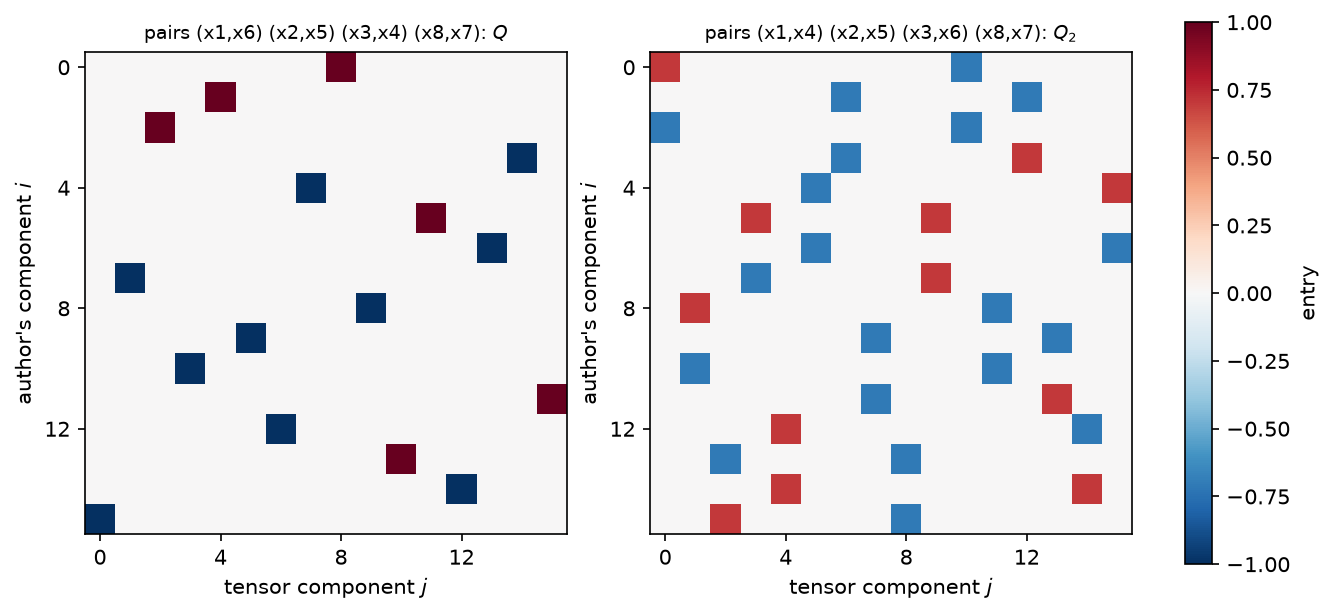

Figure 04d.6 saved as Revision/textbook/figures/04d_6_two_assignments.png


In [17]:
fig, (left, right) = plt.subplots(1, 2, figsize=(8.8, 4.6), layout="constrained")
for ax, matrix, title in (
        (left, Q, "pairs (x1,x6) (x2,x5) (x3,x4) (x8,x7): $Q$"),
        (right, Q_2, "pairs (x1,x4) (x2,x5) (x3,x6) (x8,x7): $Q_2$")):
    image = ax.imshow(matrix, cmap="RdBu_r", vmin=-1.0, vmax=1.0)
    ax.set_title(title, fontsize=9)
    ax.set_xticks(range(0, 16, 4))
    ax.set_yticks(range(0, 16, 4))
    ax.set_xlabel("tensor component $j$")
    ax.set_ylabel("author's component $i$")
    ax.grid(False)
fig.colorbar(image, ax=[left, right], shrink=0.8, label="entry")
save_figure(fig, "two_assignments",
            "The change of basis to the author's gammas for two ways of filling "
            "the slots of the tensor-product recipe (rows: the author's components, "
            "columns: the tensor components, both 0 to 15; colour scale from $-1$ "
            "blue to $+1$ red). Left: with the pairs of the author's construction "
            "the change of basis $Q$ is a signed permutation, entries $\\pm 1$. "
            "Right: with other pairs it is $Q_2$, with two entries $\\pm 1/\\sqrt{2}$ "
            "in every row and column, which mixes the components two by two. Both "
            "are orthogonal, both turn one set of gammas into the other exactly, "
            "and each is unique up to a factor.")

## 13. The last check

The last cell checks that the six figure files exist in the folder
`Revision/textbook/figures` and prints the number of checks that passed.

In [18]:
names = ["04d_1_slot_pattern.png", "04d_2_tensor_gammas.png",
         "04d_3_chirality_diagonals.png", "04d_4_change_of_basis.png",
         "04d_5_penalty_spectrum.png", "04d_6_two_assignments.png"]
check(all(output_file(f"{FIGURE_FOLDER}/{name}").is_file() for name in names),
      "all six figure files exist")
all_checks_passed()

PASS all six figure files exist
ALL 18 CHECKS PASSED (notebook 04d)


## 14. What this notebook showed

- PROVED (exact integer arithmetic): Kronecker products of the three $2 \times 2$
  matrices P, N and G give eight real $16 \times 16$ signed permutation matrices
  $\hat\gamma^{(x_a)}$ that satisfy the Clifford relation of the author's 4+4
  space-time, $\eta = \mathrm{diag}(+1, +1, +1, -1, -1, -1, -1, +1)$, with the
  author's symmetry pattern; their 256 products are a basis of all real
  $16 \times 16$ matrices (exact rank 256).
- PROVED: the chirality product of the tensor set is
  $G \otimes G \otimes G \otimes G$, diagonal with the sign $(-1)^{b_1 + b_2 + b_3 +
  b_4}$; the author's is $\mathrm{diag}(-I_8, I_8)$ (reproduces
  `Revision/algebra/reports/wolfram-algebra.json`, check `Gamma_diag`, and
  `python-algebra.json`, check `chirality_diag`).
- PROVED: the formula $S = \sum_A \gamma_A M \hat\gamma_A^T$ produces a change of
  basis; with the pairs (x1, x6), (x2, x5), (x3, x4), (x8, x7) it is $16\,Q$ with a
  signed permutation matrix $Q$, and $\gamma_A = Q\hat\gamma_A Q^T$ for all 256
  products. The author's T16 are the tensor-product gammas with the 16 components
  renumbered and some signs flipped.
- PROVED: the change of basis is unique up to a factor (the 2048 equations have
  rank 255; the penalty matrix $K$ has the eigenvalue 0 only for $Q$), and only the
  multiples of $I_{16}$ commute with all eight of the author's gammas (reproduces
  the checks `pin_commutant_dimension_1` and `Pin44_irreducible_commutant_dim_1`).
- PROVED: with other pairs in the slots the Clifford relation still holds and a
  change of basis still exists, but it mixes the components in pairs (entries
  $\pm 1/\sqrt2$), because the diagonal products then belong to different sets of
  directions.
- ASSUMED: nothing beyond the Clifford relation. These are statements of algebra:
  every equation written with the author's gammas is the same equation written with
  the tensor-product gammas after the renumbering $\Psi = Q\chi$; the choice of
  the set is a choice of basis, not of physics. The inflation of 3-space and the
  deflation of the extra times enter the field equation through the frame factors,
  the same for both sets.